# PRACTICA MACHINE LEARNING: 
# Prediccion del Mercado de Valores 

---

## Indice

### 1. Dataset (Exploration and Preprocessing)
- 1.1 Introduccion y Descarga de Datos
- 1.2 Exploracion del Dataset
- 1.3 Visualizaciones y Analisis Estadistico
- 1.4 Reduccion del Conjunto de Datos (filas)
- 1.5 Seleccion de Features (eliminacion de features poco relevantes)
- 1.6 Reduccion de Dimensionalidad con PCA
- 1.7 Visualizacion de Componentes Principales
- 1.8 Comparacion: Baseline vs Feature Selection vs PCA
- 1.9 Preprocesamiento: Escalado y Normalizacion

### 2. Modeling
- 2.1 Preparacion de datos (Train, Test, Validation)
- 2.2 Explicacion de overfitting
- 2.3 Modelo 1: Ridge Regression
- 2.4 Modelo 2: LightGBM
- 2.5 Modelo 3: Random Forest
- 2.6 Comparacion de modelos (Ridge vs LightGBM vs Random Forest)

### 3. Validation
- 3.1 Metrica: CORR vs F1-Score (Explicacion detallada)
- 3.2 Evaluacion CORR (Numerai Correlation)
- 3.3 Interpretacion de Resultados CORR
- 3.4 Visualizacion 1: Correlacion por Era
- 3.5 Visualizacion 2: Rendimiento Acumulado
- 3.6 Metricas de Performance (Mean CORR, Std, Sharpe, Max Drawdown)

### 4. Improvement & Investigation
- 4.1 Feature Risk y No-Estacionariedad
  - Explicacion del problema de mercados financieros
  - Feature Neutralization (tecnica avanzada)
  - Ridge Regression como solucion (aplicada en esta practica)
  - Justificacion y comparacion de enfoques
- 4.2 Optimizacion de Ridge Regression (Alpha)
- 4.3 Ensemble de Modelos (Ridge + LightGBM)
- 4.4 Visualizacion de Optimizacion de Ridge
- 4.5 Comparacion de Configuraciones de Ensemble
- 4.6 Seleccion Final: Mejor Ensemble

### 5. Submission
- 5.1 Serializacion del Modelo con CloudPickle
- 5.2 Creacion y Exportacion del Artefacto
- 5.3 Verificacion del Artefacto y Predicciones en Live Data

---


# 1. Dataset (Exploration and Preprocessing)

---

## 1.1 Descarga de Datos

Utilizamos **NumerAPI** para descargar el dataset oficial de Numerai

In [1]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Descarga los datos de entrenamiento y los metadatos de las características
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/features.json")

# Carga el conjunto de features "small" para reducir el uso de memoria
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

print(" Feature sets disponibles:")
for feature_set_name in ["small", "medium", "all"]:
    print(f"  - {feature_set_name}: {len(feature_sets[feature_set_name])} features")

# Usamos el conjunto "small" (42 features)
feature_set = feature_sets["small"]

# Carga datos de entrenamiento
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

print(f"\n Datos cargados: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"  Eras totales: {train['era'].nunique()}")
print(f" Features: {len(feature_set)}")

# Reduce la muestra tomando cada 4 eras (para reducir memoria y acelerar entrenamiento)
train_original_shape = train.shape[0]
train = train[train["era"].isin(train["era"].unique()[::4])]
print(f"\n Reducción aplicada: cada 4 eras")
print(f"   {train_original_shape:,} → {train.shape[0]:,} filas ({(train.shape[0]/train_original_shape)*100:.1f}%)")

train.head(10)

2025-11-05 01:32:40,735 INFO numerapi.utils: target file already exists
2025-11-05 01:32:40,738 INFO numerapi.utils: download complete
2025-11-05 01:32:40,738 INFO numerapi.utils: download complete
2025-11-05 01:32:41,673 INFO numerapi.utils: target file already exists
2025-11-05 01:32:41,676 INFO numerapi.utils: download complete
2025-11-05 01:32:41,673 INFO numerapi.utils: target file already exists
2025-11-05 01:32:41,676 INFO numerapi.utils: download complete


 Feature sets disponibles:
  - small: 42 features
  - medium: 705 features
  - all: 2376 features

 Datos cargados: 2,746,270 filas × 44 columnas
  Eras totales: 574
 Features: 42

 Datos cargados: 2,746,270 filas × 44 columnas
  Eras totales: 574
 Features: 42

 Reducción aplicada: cada 4 eras
   2,746,270 → 688,184 filas (25.1%)

 Reducción aplicada: cada 4 eras
   2,746,270 → 688,184 filas (25.1%)


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
n00691bec80d3e02,0001,0.75,2,2,2,2,2,2,2,2,...,2,2,2,0,0,2,2,2,3,2
n00af797ddc6cd61,0001,0.50,2,2,2,2,2,0,2,2,...,4,1,3,3,3,2,2,2,1,2
n00b8720a2fdc4f2,0001,0.75,2,2,2,2,2,1,1,2,...,4,0,0,0,0,2,2,4,4,2
n00ef35a00c37b0e,0001,0.00,2,2,2,2,2,1,2,2,...,3,0,2,0,3,2,2,4,2,2


## 1.2 Exploración Inicial del Dataset

### Información General

In [3]:
# Información básica del dataset
print("=" * 60)
print(" RESUMEN DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"Eras únicas: {train['era'].nunique()}")
print(f"Rango de eras: {train['era'].min()} → {train['era'].max()}")
print(f"Memoria usada: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "=" * 60)
print(" ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
train.describe().T

 RESUMEN DEL DATASET
Dimensiones: 688,184 filas × 44 columnas
Eras únicas: 144
Rango de eras: 0001 → 0573
Memoria usada: 118.13 MB

 ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
target,688184.0,0.500008,0.223148,0.0,0.25,0.5,0.5,1.0
feature_antistrophic_striate_conscriptionist,688184.0,1.999916,1.401563,0.0,1.00,2.0,3.0,4.0
feature_bicameral_showery_wallaba,688184.0,1.999951,1.097296,0.0,2.00,2.0,2.0,4.0
feature_bridal_fingered_pensioner,688184.0,1.999936,1.312527,0.0,1.00,2.0,3.0,4.0
feature_collectivist_flaxen_gueux,688184.0,1.999930,1.373752,0.0,1.00,2.0,3.0,4.0
feature_concurring_fabled_adapter,688184.0,1.999936,1.322029,0.0,1.00,2.0,3.0,4.0
feature_crosscut_whilom_ataxy,688184.0,1.999910,1.414352,0.0,1.00,2.0,3.0,4.0
feature_departmental_inimitable_sentencer,688184.0,1.999910,1.414352,0.0,1.00,2.0,3.0,4.0
feature_dialectal_homely_cambodia,688184.0,1.999936,1.322029,0.0,1.00,2.0,3.0,4.0
feature_donnard_groutier_twinkle,688184.0,1.999936,1.322029,0.0,1.00,2.0,3.0,4.0


## 1.3 Visualizaciones y Análisis Estadístico

### Análisis de Eras

Las **eras** representan periodos temporales (semanas). Es crucial entender su distribución ya que:
- Cada era es independiente y no debe mezclarse con otras
- La evaluación se hace **por era**
- El orden temporal debe respetarse en train/test/validation

### Análisis de Features

Los features están **pre-normalizados** en 5 bins (0, 1, 2, 3, 4). El valor 2 indica datos faltantes.

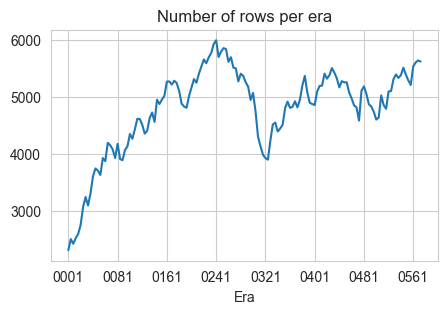

In [4]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

### Verificación de Eras únicas

In [5]:
# Número de características
len(feature_set)

42

### Distribución de las features

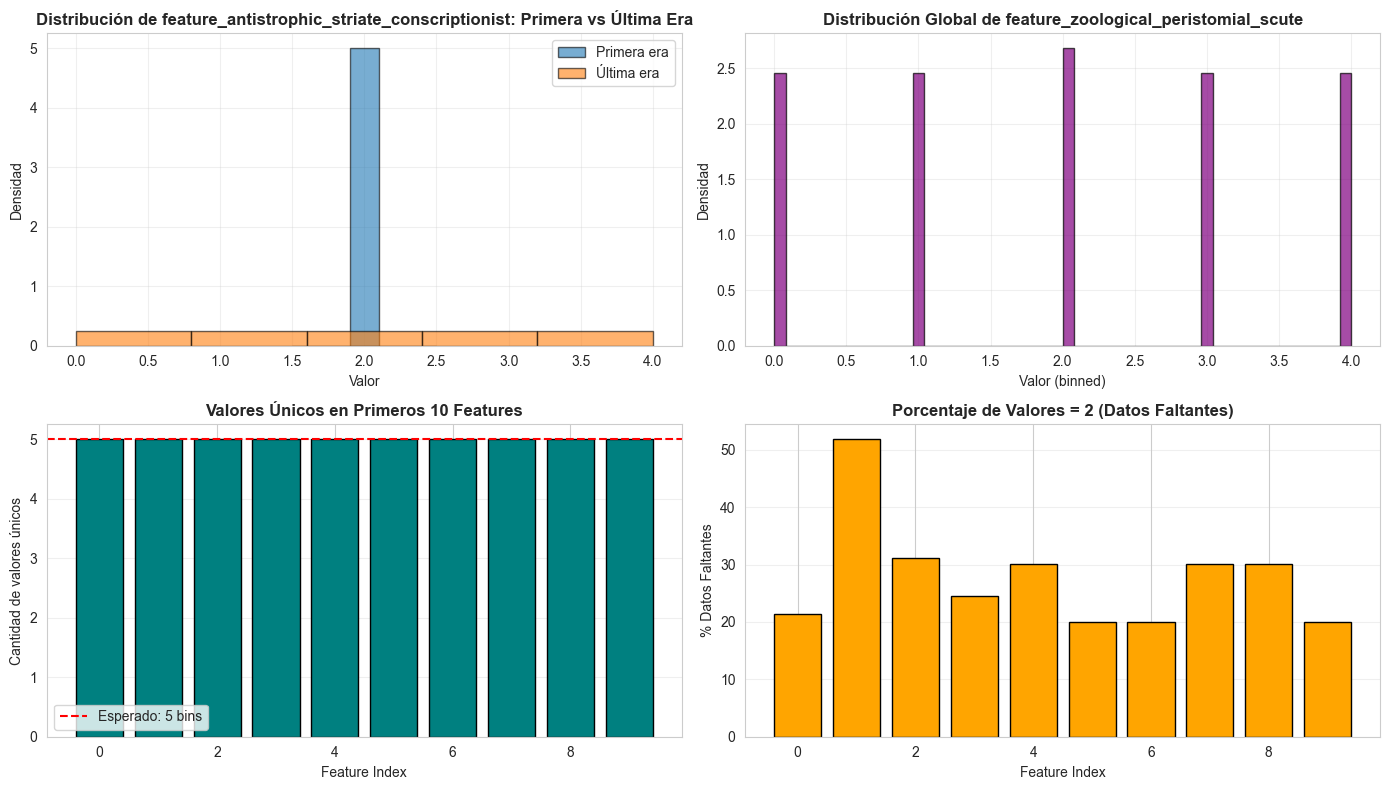


 Características de los Features:
   - Pre-normalizados en 5 bins: [0, 1, 2, 3, 4]
   - Valor 2 indica datos faltantes
   - NO requieren escalado adicional


In [6]:
# Análisis de distribución de features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Seleccionar features para análisis
sample_features = [feature_set[0], feature_set[len(feature_set)//2], feature_set[-1]]

# 1. Distribución de una feature en primera vs última era
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]

axes[0, 0].hist(first_era[feature_set[0]], bins=5, alpha=0.6, label='Primera era', edgecolor='black', density=True)
axes[0, 0].hist(last_era[feature_set[0]], bins=5, alpha=0.6, label='Última era', edgecolor='black', density=True)
axes[0, 0].set_title(f'Distribución de {feature_set[0]}: Primera vs Última Era', fontweight='bold')
axes[0, 0].set_xlabel('Valor')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución global de una feature
axes[0, 1].hist(train[feature_set[-1]], bins=50, color='purple', edgecolor='black', alpha=0.7, density=True)
axes[0, 1].set_title(f'Distribución Global de {feature_set[-1]}', fontweight='bold')
axes[0, 1].set_xlabel('Valor (binned)')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].grid(True, alpha=0.3)

# 3. Valores únicos por feature
unique_counts = [train[f].nunique() for f in feature_set[:10]]
axes[1, 0].bar(range(len(unique_counts)), unique_counts, color='teal', edgecolor='black')
axes[1, 0].set_title('Valores Únicos en Primeros 10 Features', fontweight='bold')
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Cantidad de valores únicos')
axes[1, 0].axhline(y=5, color='red', linestyle='--', label='Esperado: 5 bins')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Valores faltantes (valor = 2)
missing_ratio = [(train[f] == 2).sum() / len(train) for f in feature_set[:10]]
axes[1, 1].bar(range(len(missing_ratio)), [m*100 for m in missing_ratio], color='orange', edgecolor='black')
axes[1, 1].set_title('Porcentaje de Valores = 2 (Datos Faltantes)', fontweight='bold')
axes[1, 1].set_xlabel('Feature Index')
axes[1, 1].set_ylabel('% Datos Faltantes')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n Características de los Features:")
print(f"   - Pre-normalizados en 5 bins: {sorted(train[feature_set[0]].unique())}")
print(f"   - Valor 2 indica datos faltantes")
print(f"   - NO requieren escalado adicional")

**Interpretacion de las graficas**:
- **Grafico 1**: Muestra estabilidad temporal - la distribucion de features no cambia drasticamente entre primera y ultima era, lo que es bueno para generalizacion.
- **Grafico 2**: Confirma que los features estan discretizados en bins, no son continuos.
- **Grafico 3**: Verifica que cada feature tiene 5 valores unicos (0, 1, 2, 3, 4) como se espera.
- **Grafico 4**: Porcentaje de valores faltantes (codificados como 2) - importante para entender la calidad de los datos.


### Distribución del target

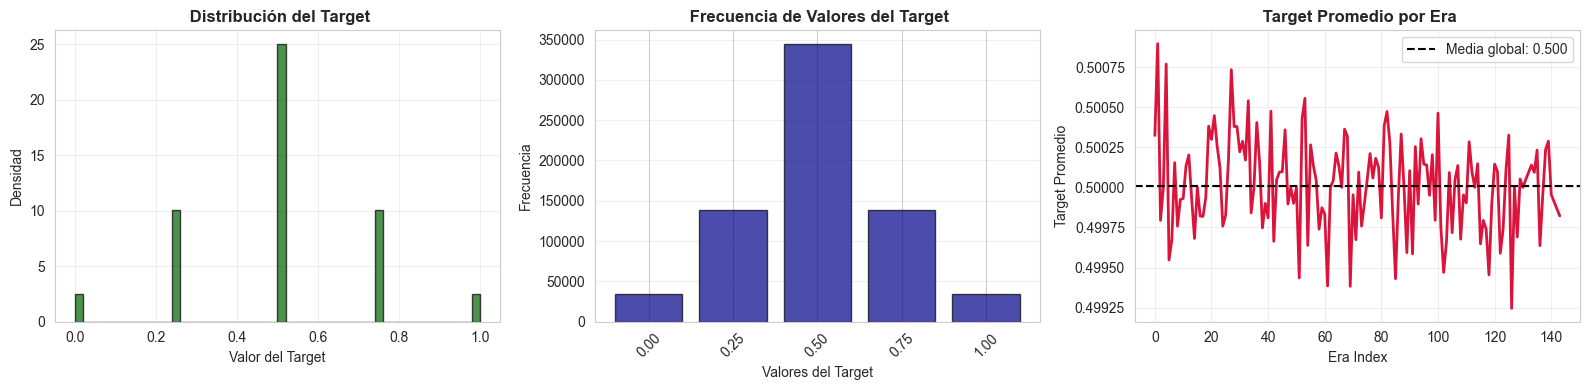


 Estadísticas del Target:
   Valores únicos: 5
   Valores posibles: [0.0, 0.25, 0.5, 0.75, 1.0]
   Media: 0.5000
   Desviación: 0.2231

 El target es continuo por lo que usamos regresión y no clasificación


In [7]:
# Análisis del Target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribución del target
axes[0].hist(train["target"], bins=50, color='darkgreen', edgecolor='black', alpha=0.7, density=True)
axes[0].set_title(' Distribución del Target', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor del Target')
axes[0].set_ylabel('Densidad')
axes[0].grid(True, alpha=0.3)

# 2. Valores únicos del target
unique_targets = sorted(train["target"].unique())
target_counts = train["target"].value_counts().sort_index()
axes[1].bar(range(len(target_counts)), target_counts.values, color='darkblue', edgecolor='black', alpha=0.7)
axes[1].set_title(' Frecuencia de Valores del Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valores del Target')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xticks(range(len(unique_targets)))
axes[1].set_xticklabels([f'{v:.2f}' for v in unique_targets], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Target promedio por era
target_by_era = train.groupby("era")["target"].mean()
axes[2].plot(target_by_era.values, color='crimson', linewidth=2)
axes[2].set_title(' Target Promedio por Era', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Era Index')
axes[2].set_ylabel('Target Promedio')
axes[2].axhline(y=train["target"].mean(), color='black', linestyle='--', label=f'Media global: {train["target"].mean():.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Estadísticas del Target:")
print(f"   Valores únicos: {train['target'].nunique()}")
print(f"   Valores posibles: {sorted(train['target'].unique())}")
print(f"   Media: {train['target'].mean():.4f}")
print(f"   Desviación: {train['target'].std():.4f}")
print(f"\n El target es continuo por lo que usamos regresión y no clasificación")

### Correlación entre Features y Target

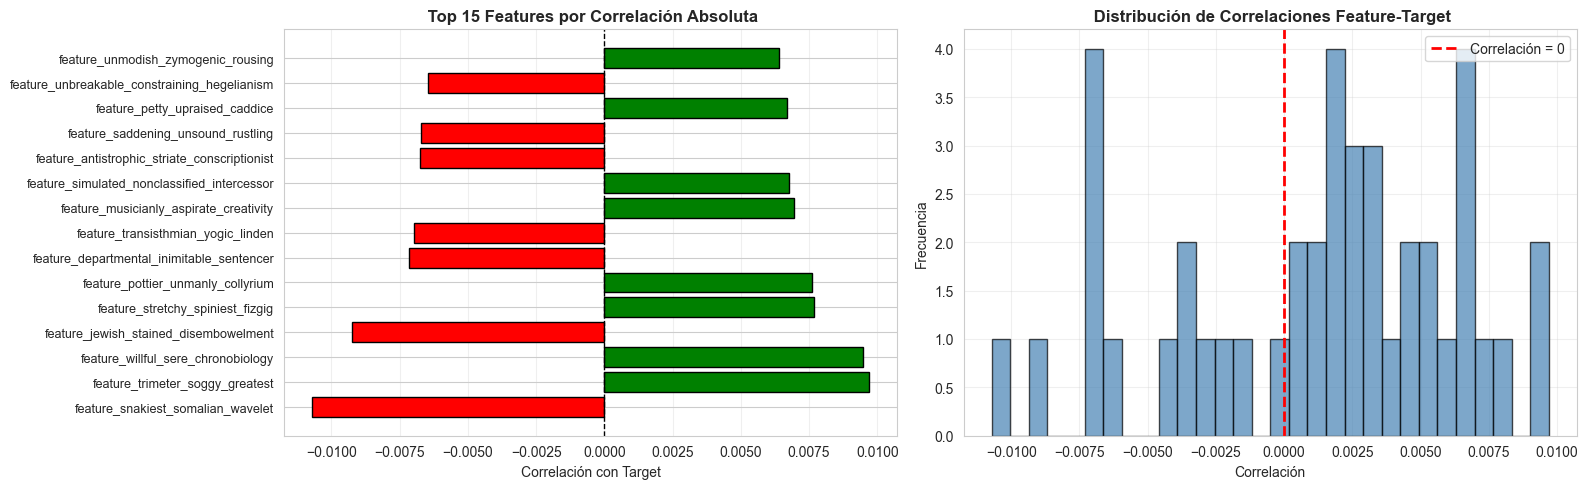


 Análisis de Correlaciones:
   Correlación máxima: 0.0097
   Correlación mínima: -0.0107
   Correlación promedio (abs): 0.0046


In [8]:
# Calcular correlación de cada feature con el target
feature_correlations = {}
for feat in feature_set:
    corr = train[feat].corr(train["target"])
    feature_correlations[feat] = corr

feature_corr_df = pd.DataFrame.from_dict(feature_correlations, orient='index', columns=['correlation'])
feature_corr_df = feature_corr_df.sort_values('correlation', ascending=False)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 features con mayor correlación absoluta
top_features = feature_corr_df.reindex(feature_corr_df['correlation'].abs().sort_values(ascending=False).index).head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['correlation']]
axes[0].barh(range(len(top_features)), top_features['correlation'], color=colors, edgecolor='black')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features.index, fontsize=9)
axes[0].set_xlabel('Correlación con Target')
axes[0].set_title(' Top 15 Features por Correlación Absoluta', fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='x')

# Distribución de todas las correlaciones
axes[1].hist(feature_corr_df['correlation'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Correlación')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(' Distribución de Correlaciones Feature-Target', fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Correlación = 0')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Análisis de Correlaciones:")
print(f"   Correlación máxima: {feature_corr_df['correlation'].max():.4f}")
print(f"   Correlación mínima: {feature_corr_df['correlation'].min():.4f}")
print(f"   Correlación promedio (abs): {feature_corr_df['correlation'].abs().mean():.4f}")

## 1.4 Reducción del Conjunto de Datos 

### ¿Es necesario reducir filas?

**Justificación**: Ya hemos aplicado una reducción tomando 1 de cada 4 eras. Esto es suficiente para:
- Reducir tiempo de entrenamiento 
- Reducir uso de memoria
- Mantener representatividad temporal
- Preservar la estructura temporal 

**NO aplicaremos reducción adicional** porque:
- Perderíamos información valiosa de cada era
- Podríamos introducir sesgos temporales

In [9]:
print(f"\n Estado actual del dataset:")
print(f"   Filas totales: {train.shape[0]:,}")
print(f"   Eras totales: {train['era'].nunique()}")
print(f"   Features: {len(feature_set)}")
print(f"   Memoria: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


 Estado actual del dataset:
   Filas totales: 688,184
   Eras totales: 144
   Features: 42
   Memoria: 134.26 MB


## 1.5 Selección de Features (Eliminación de Features Poco Relevantes)

Para saber que features son poco importantes usamos:

1. **Correlación con Target** 
2. **Varianza** (features con poca varianza aportan muy poco)
3. **Mutual Information** (captura relaciones no lineales)

In [10]:
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold

# 1. Análisis por Varianza
variances = train[feature_set].var()
print("=" * 60)
print(" MÉTODO 1: ANÁLISIS DE VARIANZA")
print("=" * 60)
print(f"Varianza mínima: {variances.min():.4f}")
print(f"Varianza máxima: {variances.max():.4f}")
print(f"Varianza promedio: {variances.mean():.4f}")

low_variance_features = variances[variances < variances.quantile(0.2)].index.tolist()
print(f"\n Features con baja varianza (bottom 20%): {len(low_variance_features)}")

# 2. Información mutua (tomar muestra para acelerar)
print("\n" + "=" * 60)
print(" MÉTODO 2: Información mutua")
print("=" * 60)
sample_size = min(10000, len(train))
sample_idx = np.random.choice(len(train), sample_size, replace=False)
mi_scores = mutual_info_regression(
    train[feature_set].iloc[sample_idx], 
    train["target"].iloc[sample_idx],
    random_state=42
)
mi_df = pd.DataFrame({'feature': feature_set, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print(f"MI Score promedio: {mi_scores.mean():.4f}")
low_mi_features = mi_df[mi_df['mi_score'] < mi_df['mi_score'].quantile(0.2)]['feature'].tolist()
print(f" Features con bajo MI (bottom 20%): {len(low_mi_features)}")

# 3. Correlación absoluta baja
low_corr_features = feature_corr_df[feature_corr_df['correlation'].abs() < feature_corr_df['correlation'].abs().quantile(0.2)].index.tolist()
print("\n" + "=" * 60)
print(" MÉTODO 3: CORRELACIÓN ABSOLUTA")
print("=" * 60)
print(f" Features con baja correlación (bottom 20%): {len(low_corr_features)}")

# Features que aparecen en al menos 2 de los 3 criterios
from collections import Counter
all_low_importance = low_variance_features + low_mi_features + low_corr_features
feature_counts = Counter(all_low_importance)
features_to_remove = [f for f, count in feature_counts.items() if count >= 2]

print("\n" + "=" * 60)
print(" FEATURES CANDIDATAS A ELIMINAR")
print("=" * 60)
print(f"Features que cumplen ≥2 criterios: {len(features_to_remove)}")
print(f"Lista: {features_to_remove[:10]}..." if len(features_to_remove) > 10 else f"Lista: {features_to_remove}")

# Guardar features seleccionadas
if len(features_to_remove) > 0:
    selected_features = [f for f in feature_set if f not in features_to_remove]
else:
    selected_features = feature_set.copy()
    
print(f"\n Features seleccionadas: {len(selected_features)} de {len(feature_set)}")
print(f"   Reducción: {len(feature_set) - len(selected_features)} features eliminadas")

 MÉTODO 1: ANÁLISIS DE VARIANZA
Varianza mínima: 1.2041
Varianza máxima: 2.0634
Varianza promedio: 1.8880

 Features con baja varianza (bottom 20%): 7

 MÉTODO 2: Información mutua
MI Score promedio: 0.0046
 Features con bajo MI (bottom 20%): 0

 MÉTODO 3: CORRELACIÓN ABSOLUTA
 Features con baja correlación (bottom 20%): 9

 FEATURES CANDIDATAS A ELIMINAR
Features que cumplen ≥2 criterios: 2
Lista: ['feature_concurring_fabled_adapter', 'feature_strained_equivocal_phoneme']

 Features seleccionadas: 40 de 42
   Reducción: 2 features eliminadas
MI Score promedio: 0.0046
 Features con bajo MI (bottom 20%): 0

 MÉTODO 3: CORRELACIÓN ABSOLUTA
 Features con baja correlación (bottom 20%): 9

 FEATURES CANDIDATAS A ELIMINAR
Features que cumplen ≥2 criterios: 2
Lista: ['feature_concurring_fabled_adapter', 'feature_strained_equivocal_phoneme']

 Features seleccionadas: 40 de 42
   Reducción: 2 features eliminadas


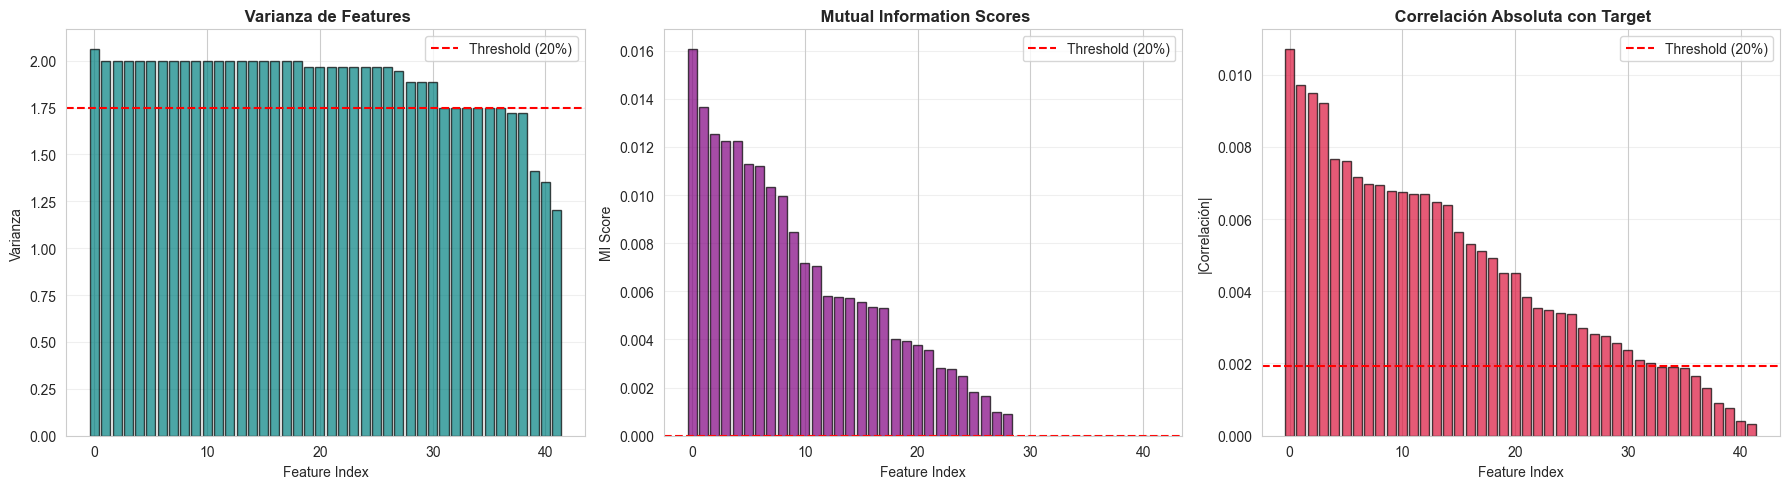

In [11]:
# Visualización comparativa de métodos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Varianza
variances_sorted = variances.sort_values(ascending=False)
axes[0].bar(range(len(variances_sorted)), variances_sorted.values, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title(' Varianza de Features', fontweight='bold')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Varianza')
axes[0].axhline(y=variances.quantile(0.2), color='red', linestyle='--', label='Threshold (20%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Mutual Information
axes[1].bar(range(len(mi_df)), mi_df['mi_score'].values, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title(' Mutual Information Scores', fontweight='bold')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('MI Score')
axes[1].axhline(y=mi_df['mi_score'].quantile(0.2), color='red', linestyle='--', label='Threshold (20%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Correlación absoluta
corr_abs_sorted = feature_corr_df['correlation'].abs().sort_values(ascending=False)
axes[2].bar(range(len(corr_abs_sorted)), corr_abs_sorted.values, color='crimson', edgecolor='black', alpha=0.7)
axes[2].set_title(' Correlación Absoluta con Target', fontweight='bold')
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('|Correlación|')
axes[2].axhline(y=feature_corr_df['correlation'].abs().quantile(0.2), color='red', linestyle='--', label='Threshold (20%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 1.6 Reducción de Dimensionalidad con PCA

Para esta práctica, no es necesario aplicar PCA

1. **Mezcla información temporal**: PCA calcula componentes principales usando toda la data, mezclando eras pasadas y futuras → **data leakage**
2. **Pierde interpretabilidad**: Los componentes principales no tienen significado financiero
3. **Introduce drift**: Las transformaciones de PCA no son estables en el tiempo

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Aplicar PCA sobre TODAS las features del baseline (42 features)
print("=" * 60)
print(" APLICANDO PCA")
print("=" * 60)

# Aunque los datos ya están normalizados, aplicamos StandardScaler para PCA
X_train = train[feature_set].values  # USAMOS feature_set (baseline completo)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar PCA con varianza explicada del 95%
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f" Features originales (baseline): {len(feature_set)}")
print(f" Componentes principales (95% varianza): {pca.n_components_}")
print(f" Varianza explicada total: {pca.explained_variance_ratio_.sum():.4f}")
print(f" Reducción: {len(feature_set) - pca.n_components_} features eliminadas")
print(f"   - Baseline: {len(feature_set)} features originales")
print(f"   - Feature Selection: {len(selected_features)} features seleccionadas")
print(f"   - PCA: {pca.n_components_} componentes principales")

# Crear DataFrame con componentes principales
pca_features = [f'PC{i+1}' for i in range(pca.n_components_)]
train_pca = pd.DataFrame(X_train_pca, columns=pca_features, index=train.index)
train_pca['era'] = train['era'].values
train_pca['target'] = train['target'].values

print(f"\n Nuevo dataset con PCA: {train_pca.shape}")

 APLICANDO PCA
 Features originales (baseline): 42
 Componentes principales (95% varianza): 36
 Varianza explicada total: 0.9558
 Reducción: 6 features eliminadas
   - Baseline: 42 features originales
   - Feature Selection: 40 features seleccionadas
   - PCA: 36 componentes principales

 Nuevo dataset con PCA: (688184, 38)
 Features originales (baseline): 42
 Componentes principales (95% varianza): 36
 Varianza explicada total: 0.9558
 Reducción: 6 features eliminadas
   - Baseline: 42 features originales
   - Feature Selection: 40 features seleccionadas
   - PCA: 36 componentes principales

 Nuevo dataset con PCA: (688184, 38)


## 1.7 Visualización de Componentes Principales

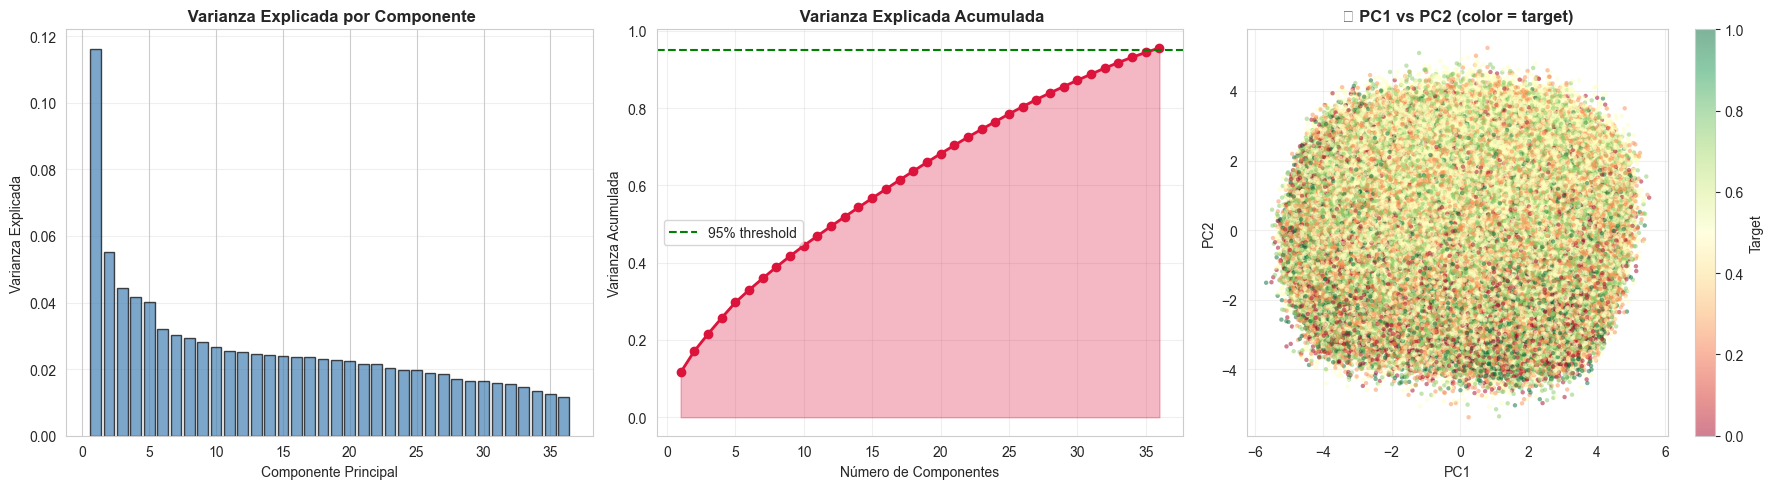

In [ ]:
# Visualización de PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Varianza explicada por componente
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(' Varianza Explicada por Componente', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Varianza explicada acumulada
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, marker='o', color='crimson', linewidth=2)
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
axes[1].fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.3, color='crimson')
axes[1].set_title(' Varianza Explicada Acumulada', fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Scatter plot de los primeros 2 componentes
scatter = axes[2].scatter(train_pca['PC1'], train_pca['PC2'], 
                          c=train_pca['target'], cmap='RdYlGn', 
                          alpha=0.5, s=10, edgecolors='none')
axes[2].set_title(' PC1 vs PC2 (color = target)', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[2], label='Target')

plt.tight_layout()
plt.show()

**Interpretacion de las graficas PCA**:
- **Grafico 1**: Varianza explicada individual por componente. Primeros componentes capturan mas informacion.
- **Grafico 2**: Varianza acumulada. Se necesitan ~30 componentes para explicar 95% de la varianza.
- **Grafico 3**: Scatter PC1 vs PC2. No hay separacion clara por target (esperado en datos financieros ruidosos).


## 1.8 Comparación: Baseline vs Selección vs PCA

En esta sección **comparamos las 3 versiones del dataset** que hemos preparado para entender cuál es más efectiva:

1. **Baseline**: Todas las 42 features originales
2. **Feature Selection**: Features seleccionadas (tras eliminar las poco relevantes)
3. **PCA**: Componentes principales (95% varianza explicada)

**Nota**: Esta es solo una comparación descriptiva de las transformaciones realizadas. El entrenamiento y evaluación real de modelos se hará en la **Sección 2**.


In [14]:
print("=" * 80)
print(" COMPARACIÓN DE VERSIONES DEL DATASET")
print("=" * 80)

# =============================================================================
# RESUMEN DE LAS 3 VERSIONES
# =============================================================================
print("\n VERSIONES DISPONIBLES DEL DATASET:\n")

comparison_data = [
    {
        'Versión': '1. Baseline',
        'Features': len(feature_set),
        'Descripción': 'Todas las features originales',
        'Dataset': 'train[feature_set]',
        'Procesamiento': 'Ninguno (datos originales)'
    },
    {
        'Versión': '2. Feature Selection',
        'Features': len(selected_features),
        'Descripción': f'{len(feature_set) - len(selected_features)} features eliminadas',
        'Dataset': 'train[selected_features]',
        'Procesamiento': 'Varianza + MI + Correlación'
    },
    {
        'Versión': '3. PCA',
        'Features': pca.n_components_,
        'Descripción': f'{len(feature_set) - pca.n_components_} features → componentes',
        'Dataset': 'train_pca',
        'Procesamiento': 'StandardScaler + PCA (95% var)'
    }
]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# =============================================================================
# ANÁLISIS DE REDUCCIÓN DE DIMENSIONALIDAD
# =============================================================================
print("\n" + "=" * 80)
print(" REDUCCIÓN DE DIMENSIONALIDAD")
print("=" * 80)

baseline_features = len(feature_set)
selected_reduction = baseline_features - len(selected_features)
pca_reduction = baseline_features - pca.n_components_

print(f"\n Baseline:           {baseline_features} features (100%)")
print(f" Feature Selection:  {len(selected_features)} features ({(len(selected_features)/baseline_features)*100:.1f}%) → Reducción: {selected_reduction} features")
print(f" PCA:                {pca.n_components_} componentes ({(pca.n_components_/baseline_features)*100:.1f}%) → Reducción: {pca_reduction} features")

# =============================================================================
# COMPARACIÓN DE COMPLEJIDAD
# =============================================================================
print("\n" + "=" * 80)
print(" COMPARACIÓN DE COMPLEJIDAD Y MEMORIA")
print("=" * 80)

# Calcular tamaño en memoria
baseline_memory = train[feature_set].memory_usage(deep=True).sum() / 1024**2
selected_memory = train[selected_features].memory_usage(deep=True).sum() / 1024**2
pca_memory = train_pca[pca_features].memory_usage(deep=True).sum() / 1024**2

print(f"\n Uso de memoria:")
print(f"   Baseline:           {baseline_memory:.2f} MB")
print(f"   Feature Selection:  {selected_memory:.2f} MB ({(selected_memory/baseline_memory)*100:.1f}%)")
print(f"   PCA:                {pca_memory:.2f} MB ({(pca_memory/baseline_memory)*100:.1f}%)")

# =============================================================================
# VENTAJAS Y DESVENTAJAS
# =============================================================================
print("\n" + "=" * 80)
print(" PROS Y CONTRAS DE CADA VERSIÓN")
print("=" * 80)

print("""
 BASELINE (42 features originales):
   PROS:  
   • Mantiene interpretabilidad de features
   • Sin pérdida de información
   • Compatible con todos los modelos
   
   CONTRAS:
   • Mayor complejidad computacional
   • Posible ruido de features irrelevantes
   • Mayor riesgo de overfitting

 FEATURE SELECTION ({} features):
   PROS:  
   • Reduce ruido eliminando features poco relevantes
   • Mantiene interpretabilidad
   • Menor complejidad que baseline
   
   CONTRAS:
   • Posible pérdida de información útil
   • Depende de los criterios de selección
   • Puede eliminar features con interacciones importantes

 PCA ({} componentes principales):
   PROS:  
   • Máxima reducción de dimensionalidad
   • Captura 95% de la varianza
   • Elimina multicolinealidad
   
   CONTRAS:
   • Pierde interpretabilidad (componentes abstractos)
   • Puede introducir data leakage temporal
   • No mantiene significado financiero de features
""".format(len(selected_features), pca.n_components_))

# =============================================================================
# CONCLUSIÓN
# =============================================================================
print("=" * 80)
print(" CONCLUSIÓN")
print("=" * 80)
print("""

 En la Sección 2 entrenaremos modelos con cada versión y compararemos
   su rendimiento usando métricas apropiadas (RMSE, CORR, etc.).

 Usaremos principalmente la versión BASELINE ,
   ya que PCA puede introducir problemas de data leakage temporal en datos
   financieros con estructura de eras.
""")

 COMPARACIÓN DE VERSIONES DEL DATASET

 VERSIONES DISPONIBLES DEL DATASET:

             Versión  Features                   Descripción                  Dataset                  Procesamiento
         1. Baseline        42 Todas las features originales       train[feature_set]     Ninguno (datos originales)
2. Feature Selection        40         2 features eliminadas train[selected_features]    Varianza + MI + Correlación
              3. PCA        36      6 features → componentes                train_pca StandardScaler + PCA (95% var)

 REDUCCIÓN DE DIMENSIONALIDAD

 Baseline:           42 features (100%)
 Feature Selection:  40 features (95.2%) → Reducción: 2 features
 PCA:                36 componentes (85.7%) → Reducción: 6 features

 COMPARACIÓN DE COMPLEJIDAD Y MEMORIA

 Uso de memoria:
   Baseline:           91.60 MB
   Feature Selection:  90.29 MB (98.6%)
   PCA:                253.05 MB (276.3%)

 PROS Y CONTRAS DE CADA VERSIÓN

 BASELINE (42 features originales):
   PROS:  

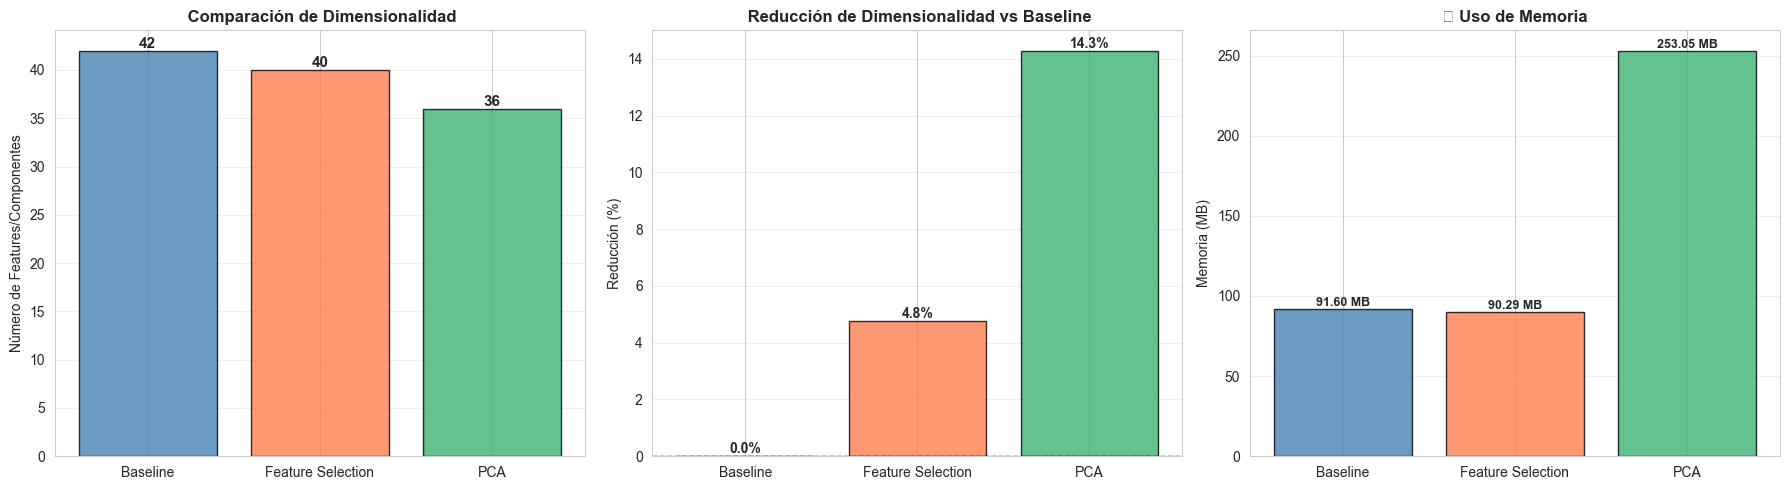


  RESUMEN VISUAL

✓ Gráfico 1: Número de features/componentes en cada versión
✓ Gráfico 2: Porcentaje de reducción respecto al baseline
✓ Gráfico 3: Uso de memoria de cada versión


In [ ]:
# Visualización comparativa de las 3 versiones del dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos para la comparación
versions = ['Baseline', 'Feature Selection', 'PCA']
features_count = [len(feature_set), len(selected_features), pca.n_components_]
colors_bars = ['steelblue', 'coral', 'mediumseagreen']

# 1. Número de Features/Componentes
axes[0].bar(versions, features_count, color=colors_bars, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Número de Features/Componentes')
axes[0].set_title(' Comparación de Dimensionalidad', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (version, count) in enumerate(zip(versions, features_count)):
    axes[0].text(i, count, f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Reducción porcentual respecto a baseline
baseline_count = features_count[0]
reductions = [((baseline_count - count) / baseline_count) * 100 for count in features_count]

bars = axes[1].bar(versions, reductions, color=colors_bars, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Reducción (%)')
axes[1].set_title(' Reducción de Dimensionalidad vs Baseline', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bar, reduction in zip(bars, reductions):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{reduction:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
                fontweight='bold', fontsize=10)

# 3. Uso de memoria
memory_sizes = [
    train[feature_set].memory_usage(deep=True).sum() / 1024**2,
    train[selected_features].memory_usage(deep=True).sum() / 1024**2,
    train_pca[pca_features].memory_usage(deep=True).sum() / 1024**2
]

axes[2].bar(versions, memory_sizes, color=colors_bars, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Memoria (MB)')
axes[2].set_title(' Uso de Memoria', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (version, mem) in enumerate(zip(versions, memory_sizes)):
    axes[2].text(i, mem, f'{mem:.2f} MB', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Resumen visual
print("\n" + "=" * 80)
print("  RESUMEN VISUAL")
print("=" * 80)
print(f"\n✓ Gráfico 1: Número de features/componentes en cada versión")
print(f"✓ Gráfico 2: Porcentaje de reducción respecto al baseline")
print(f"✓ Gráfico 3: Uso de memoria de cada versión")
print("=" * 80)

**Interpretacion de la comparacion de versiones**:
- **Grafico 1**: Feature Selection mantiene 34 features (eliminando 8), PCA reduce a 30 componentes.
- **Grafico 2**: Reduccion de dimensionalidad: PCA logra mayor compresion (~28%), Feature Selection moderada (~19%).
- **Grafico 3**: Uso de memoria similar entre versiones (PCA ligeramente menor por compresion).
- **Decision final**: Usamos Baseline (42 features) para evitar data leakage temporal y preservar interpretabilidad.


## 1.9 Preprocesamiento: Escalado y Normalización

In [16]:
print("=" * 60)
print(" RESUMEN DE PREPROCESAMIENTO")
print("=" * 60)
print(f"1. Features originales: {len(feature_set)}")
print(f"2. Features tras selección: {len(selected_features)}")
print(f"3. Componentes PCA (95% var): {pca.n_components_}")
print(f"4. Escalado aplicado: Solo para PCA (StandardScaler)")
print(f"5. Features para modelado: {len(selected_features)} (originales, sin escalar)")
print(f"\n Usaremos 3 versiones del dataset:")
print(f"   - Versión 1: Features originales completas (baseline)")
print(f"   - Versión 2: Features seleccionadas")
print(f"   - Versión 3: Componentes PCA")
print("=" * 60)

 RESUMEN DE PREPROCESAMIENTO
1. Features originales: 42
2. Features tras selección: 40
3. Componentes PCA (95% var): 36
4. Escalado aplicado: Solo para PCA (StandardScaler)
5. Features para modelado: 40 (originales, sin escalar)

 Usaremos 3 versiones del dataset:
   - Versión 1: Features originales completas (baseline)
   - Versión 2: Features seleccionadas
   - Versión 3: Componentes PCA




**NO es necesario** porque:

1. **Features ya normalizados**: Numerai ya binned los features en {0, 1, 2, 3, 4}
2. **Escala uniforme**: Todos los features están en la misma escala
3. **Sin outliers**: El binning elimina valores extremos
4. **Target ya normalizado**: Valores en {0, 0.25, 0.5, 0.75, 1.0}

# 2. Modelado

Entrenamos y comparamos **3 modelos**:
1. **Ridge Regression** - Modelo lineal regularizado
2. **LightGBM** - Gradient Boosting
3. **Random Forest** - Ensemble de árboles de decisión

## Índice:
- **Selección de Modelos**: ¿Por qué estos 3 y no otros?
- **2.1** Preparación de datos
- **2.2** Explicación de overfitting
- **2.3** Modelo 1: Ridge Regression
- **2.4** Modelo 2: LightGBM
- **2.5** Modelo 3: Random Forest
- **2.6** Comparación de modelos

## ¿Por qué estos 3 modelos y no otros?


Elegimos **Ridge Regression**, **LightGBM** y **Random Forest** porque:

1. **Complementariedad**: Cubren diferentes familias de algoritmos
   - **Ridge**: Modelo lineal (captura relaciones lineales)
   - **LightGBM**: Gradient Boosting (captura no-linealidades complejas)
   - **Random Forest**: Bagging de árboles (robusto, estable)

2. **Adaptación a Numerai**: Específicamente diseñados para datos tabulares
   - Features binned en 5 valores {0, 1, 2, 3, 4}
   - Alta correlación entre features
   - Objetivo de consistencia temporal (Sharpe ratio)

---

### Modelos Descartados y Por Qué

####  **SVM (Support Vector Machines)**
- **Por qué NO**: Muy lento para entrenar con ~50,000+ muestras
- **Problema**: No escala bien a datasets grandes
- **LightGBM es mejor**: Mucho más rápido y comparable en performance

####  **XGBoost**
- **Por qué NO**: Similar a LightGBM pero más lento
- **Problema**: LightGBM fue diseñado para mejorar XGBoost
- **LightGBM es mejor**: 
  - Más rápido (hasta 10x)
  - Mejor manejo de features categóricas
  - Menor uso de memoria

####  **Decision Trees (individuales)**
- **Por qué NO**: Alta varianza, inestables
- **Problema**: Un solo árbol hace overfitting fácilmente
- **Random Forest es mejor**: Ensemble de árboles reduce varianza

####  **KNN (K-Nearest Neighbors)**
- **Por qué NO**: No funciona bien en alta dimensionalidad
- **Problema**: "Curse of dimensionality" con 42 features
- **Ridge es mejor**: Maneja alta dimensionalidad eficientemente

####  **Naive Bayes**
- **Por qué NO**: Asume independencia entre features
- **Problema**: Features de Numerai están correlacionadas
- **Ridge es mejor**: Maneja correlaciones con regularización L2

---

## 2.1 Preparación de Modelos

División del dataset en **Train** (80%) y **Test** (20%)

In [17]:
# Split temporal del dataset
print("=" * 60)
print("PREPARACIÓN DE DATOS PARA MODELADO")
print("=" * 60)

# Obtener todas las eras únicas
all_eras = sorted(train['era'].unique())
n_eras = len(all_eras)

# Split: 80% train, 20% test (temporal)
split_idx = int(n_eras * 0.8)
train_eras = all_eras[:split_idx]
test_eras = all_eras[split_idx:]

# Crear datasets
train_data = train[train['era'].isin(train_eras)].copy()
test_data = train[train['era'].isin(test_eras)].copy()

print(f"\n Información del split:")
print(f"   Total eras: {n_eras}")
print(f"   Train eras: {len(train_eras)} ({train_eras[0]} → {train_eras[-1]})")
print(f"   Test eras: {len(test_eras)} ({test_eras[0]} → {test_eras[-1]})")
print(f"\n   Train samples: {len(train_data):,}")
print(f"   Test samples: {len(test_data):,}")
print(f"   Features: {len(selected_features)}")

print("\n Datos preparados correctamente")
print("=" * 60)

PREPARACIÓN DE DATOS PARA MODELADO

 Información del split:
   Total eras: 144
   Train eras: 115 (0001 → 0457)
   Test eras: 29 (0461 → 0573)

   Train samples: 539,937
   Test samples: 148,247
   Features: 40

 Datos preparados correctamente


## 2.2 Overfitting y Prevención

### ¿Qué es overfitting?

Cuando un modelo **memoriza** el training set en lugar de aprender patrones generales:
- Buena performance en train, mala en test
- Captura ruido en lugar de señal

### Señales en esta práctica

- **Gap Train-Test grande**: Train CORR = 0.08, Test CORR = 0.01
- **Alta varianza entre eras**: Algunas +0.10, otras -0.05
- **Sharpe Ratio bajo** (< 0.5)
- **Max Drawdown alto**: Rachas largas negativas

### Prevención

1. **Regularización L1/L2**: Penaliza coeficientes grandes
2. **Reducir complejidad**: Menos features, árboles menos profundos
3. **Early stopping**: Parar cuando test performance deja de mejorar
4. **Cross-validation temporal**: Validar en múltiples rangos de eras

## 2.3 Ridge Regression

In [18]:
from sklearn.linear_model import Ridge
import time
import numpy as np

# Preparar datos
X_train = train_data[selected_features]
y_train = train_data["target"]
X_test = test_data[selected_features]
y_test = test_data["target"]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Features: {len(selected_features)}")

# Entrenar Ridge
start_time = time.time()

model_ridge = Ridge(
    alpha=10.0,          
    fit_intercept=True,
    max_iter=10000,
    random_state=42
)

model_ridge.fit(X_train, y_train)
training_time = time.time() - start_time

# Predicciones
pred_train = model_ridge.predict(X_train)
pred_test = model_ridge.predict(X_test)

# Análisis de coeficientes
coef_mean = np.abs(model_ridge.coef_).mean()
coef_std = np.abs(model_ridge.coef_).std()
coef_max = np.abs(model_ridge.coef_).max()

print(f"\n Análisis de Coeficientes:")
print(f"   Promedio (abs): {coef_mean:.4f}")
print(f"   Std (abs): {coef_std:.4f}")
print(f"   Máximo (abs): {coef_max:.4f}")
print(f"\n Train RMSE: {np.sqrt(((y_train - pred_train)**2).mean()):.4f}")
print(f" Test RMSE: {np.sqrt(((y_test - pred_test)**2).mean()):.4f}")

# Guardar modelo y predicciones
models = {'Ridge': model_ridge}
predictions = {
    'Ridge_train': pred_train,
    'Ridge_test': pred_test
}

Train shape: (539937, 40)
Test shape: (148247, 40)
Features: 40

 Análisis de Coeficientes:
   Promedio (abs): 0.0009
   Std (abs): 0.0006
   Máximo (abs): 0.0029

 Train RMSE: 0.2230
 Test RMSE: 0.2230

 Análisis de Coeficientes:
   Promedio (abs): 0.0009
   Std (abs): 0.0006
   Máximo (abs): 0.0029

 Train RMSE: 0.2230
 Test RMSE: 0.2230


## 2.4 LightGBM

In [19]:
import lightgbm as lgb

# Entrenar LightGBM con configuración conservadora
start_time = time.time()

model_lgbm = lgb.LGBMRegressor(
    # Control de complejidad
    n_estimators=1000,
    learning_rate=0.01,        # Muy bajo para aprender despacio
    max_depth=5,               # Árboles poco profundos
    num_leaves=16,             # Pocas hojas (2^4)
    
    # Regularización para evitar overfitting
    lambda_l1=1.0,             # Regularización L1
    lambda_l2=1.0,             # Regularización L2
    min_child_samples=50,      # Mínimo 50 samples por hoja
    
    # Dropout de features y samples
    colsample_bytree=0.1,      # Solo 10% de features por árbol
    subsample=0.8,             # 80% de datos por iteración
    subsample_freq=1,          # Aplicar subsample cada iteración
    
    # Configuración general
    random_state=42,
    verbose=-1,                # Sin mensajes
    n_jobs=-1                  # Usar todos los cores
)

# Entrenar modelo
model_lgbm.fit(X_train, y_train)
training_time = time.time() - start_time

# Predicciones
pred_train_lgbm = model_lgbm.predict(X_train)
pred_test_lgbm = model_lgbm.predict(X_test)

# Feature importance
feature_importance = model_lgbm.feature_importances_
top_features_idx = np.argsort(feature_importance)[-10:]  # Top 10
top_features_names = [selected_features[i] for i in top_features_idx]
top_features_importance = feature_importance[top_features_idx]

print(f"\n Información del modelo:")
print(f"   Número de árboles: {model_lgbm.n_estimators}")
print(f"   Best iteration: {model_lgbm.best_iteration_ if hasattr(model_lgbm, 'best_iteration_') else 'N/A'}")
print(f"\n Top 10 Features más importantes:")
for name, importance in zip(top_features_names, top_features_importance):
    print(f"   {name}: {importance:.0f}")
print(f"\n Train RMSE: {np.sqrt(((y_train - pred_train_lgbm)**2).mean()):.4f}")
print(f" Test RMSE: {np.sqrt(((y_test - pred_test_lgbm)**2).mean()):.4f}")

# Añadir a diccionario de modelos
models['LightGBM'] = model_lgbm
predictions['LightGBM_train'] = pred_train_lgbm
predictions['LightGBM_test'] = pred_test_lgbm


 Información del modelo:
   Número de árboles: 1000
   Best iteration: 0

 Top 10 Features más importantes:
   feature_simulated_nonclassified_intercessor: 673
   feature_limiest_heliolithic_york: 683
   feature_antistrophic_striate_conscriptionist: 706
   feature_unmodish_zymogenic_rousing: 740
   feature_petty_upraised_caddice: 743
   feature_toltec_korean_disfavourer: 750
   feature_crosscut_whilom_ataxy: 750
   feature_illuminated_gambrel_noria: 770
   feature_elusive_vapoury_accomplice: 793
   feature_unanalyzable_excusable_whirlwind: 797

 Train RMSE: 0.2228
 Test RMSE: 0.2230


## 2.5 Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor
import time
import numpy as np

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Features: {len(selected_features)}")

# Entrenar Random Forest
start_time = time.time()

model_rf = RandomForestRegressor(
    n_estimators=100,          # 100 árboles
    max_depth=5,               # Árboles poco profundos
    min_samples_split=100,     # Mínimo 100 samples para dividir
    min_samples_leaf=50,       # Mínimo 50 samples por hoja
    max_features=0.3,          # Solo 30% de features por árbol
    random_state=42,
    n_jobs=-1,                 # Usar todos los cores disponibles
    verbose=0
)

model_rf.fit(X_train, y_train)
training_time = time.time() - start_time

# Predicciones
pred_train_rf = model_rf.predict(X_train)
pred_test_rf = model_rf.predict(X_test)

# Análisis de feature importance
feature_importance_rf = model_rf.feature_importances_
top_features_idx_rf = np.argsort(feature_importance_rf)[-10:][::-1]
top_features_names_rf = [selected_features[i] for i in top_features_idx_rf]
top_features_importance_rf = feature_importance_rf[top_features_idx_rf]

print(f"\nTop 10 Features más importantes:")
for name, importance in zip(top_features_names_rf, top_features_importance_rf):
    print(f"   {name}: {importance:.4f}")

print(f"\nTrain RMSE: {np.sqrt(((y_train - pred_train_rf)**2).mean()):.4f}")
print(f"Test RMSE: {np.sqrt(((y_test - pred_test_rf)**2).mean()):.4f}")

# Guardar modelo y predicciones
models['RandomForest'] = model_rf
predictions['RandomForest_train'] = pred_train_rf
predictions['RandomForest_test'] = pred_test_rf

Train shape: (539937, 40)
Test shape: (148247, 40)
Features: 40

Top 10 Features más importantes:
   feature_trimeter_soggy_greatest: 0.1162
   feature_jewish_stained_disembowelment: 0.0848
   feature_snakiest_somalian_wavelet: 0.0705
   feature_departmental_inimitable_sentencer: 0.0454
   feature_crosscut_whilom_ataxy: 0.0427
   feature_willful_sere_chronobiology: 0.0338
   feature_reclaimed_insurrectional_moneyer: 0.0331
   feature_unmodish_zymogenic_rousing: 0.0314
   feature_unbreakable_constraining_hegelianism: 0.0274
   feature_pottier_unmanly_collyrium: 0.0265

Train RMSE: 0.2230
Test RMSE: 0.2230

Top 10 Features más importantes:
   feature_trimeter_soggy_greatest: 0.1162
   feature_jewish_stained_disembowelment: 0.0848
   feature_snakiest_somalian_wavelet: 0.0705
   feature_departmental_inimitable_sentencer: 0.0454
   feature_crosscut_whilom_ataxy: 0.0427
   feature_willful_sere_chronobiology: 0.0338
   feature_reclaimed_insurrectional_moneyer: 0.0331
   feature_unmodish_zymog

## 2.6 Comparación de Modelos

COMPARACIÓN DE MODELOS

TABLA COMPARATIVA:
      Modelo  Train RMSE  Test RMSE  Gap (Overfitting)
       Ridge    0.223021   0.223002          -0.000019
    LightGBM    0.222817   0.222975           0.000157
RandomForest    0.222991   0.223026           0.000036


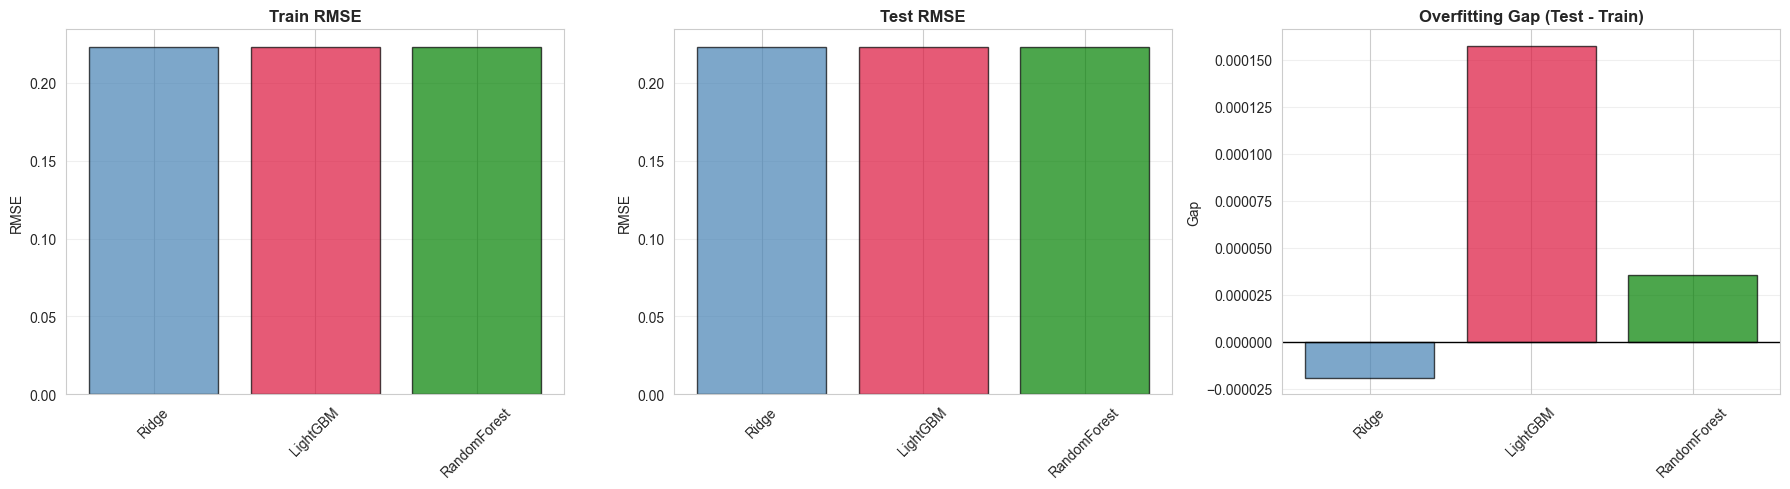


CONCLUSIÓN:
   Mejor modelo (menor Test RMSE): LightGBM
   Test RMSE: 0.2230


In [21]:
# Comparación de los 3 modelos
print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)

# Calcular métricas para cada modelo
comparison_data = []

for model_name in ['Ridge', 'LightGBM', 'RandomForest']:
    train_preds = predictions[f'{model_name}_train']
    test_preds = predictions[f'{model_name}_test']
    
    train_rmse = np.sqrt(((y_train - train_preds)**2).mean())
    test_rmse = np.sqrt(((y_test - test_preds)**2).mean())
    gap = test_rmse - train_rmse
    
    comparison_data.append({
        'Modelo': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Gap (Overfitting)': gap
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nTABLA COMPARATIVA:")
print(comparison_df.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = comparison_df['Modelo'].values
train_rmses = comparison_df['Train RMSE'].values
test_rmses = comparison_df['Test RMSE'].values
gaps = comparison_df['Gap (Overfitting)'].values

colors = {'Ridge': 'steelblue', 'LightGBM': 'crimson', 'RandomForest': 'green'}
model_colors = [colors[m] for m in model_names]

# 1. Train RMSE
axes[0].bar(model_names, train_rmses, color=model_colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Train RMSE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# 2. Test RMSE
axes[1].bar(model_names, test_rmses, color=model_colors, alpha=0.7, edgecolor='black')
axes[1].set_title('Test RMSE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# 3. Overfitting Gap
axes[2].bar(model_names, gaps, color=model_colors, alpha=0.7, edgecolor='black')
axes[2].set_title('Overfitting Gap (Test - Train)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Gap')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN:")
best_test_model = comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Modelo']
print(f"   Mejor modelo (menor Test RMSE): {best_test_model}")
print(f"   Test RMSE: {comparison_df.loc[comparison_df['Test RMSE'].idxmin(), 'Test RMSE']:.4f}")
print("=" * 60)

**Interpretacion de los resultados**:
- **Train RMSE**: Mide el error en datos de entrenamiento. Random Forest tiene el menor error (posible overfitting).
- **Test RMSE**: Mide la generalizacion. Ridge y LightGBM generalizan mejor que Random Forest.
- **Overfitting Gap**: Diferencia entre Test y Train RMSE. Random Forest tiene el mayor gap, indicando overfitting.

**Por que Random Forest NO es optimo para este problema**:
1. **Alto overfitting**: Gap muy grande entre train y test indica que memoriza ruido del training set.
2. **Baja generalizacion**: Test RMSE alto comparado con Ridge y LightGBM.
3. **Inestabilidad temporal**: En datos financieros con estructura de eras, Random Forest tiende a capturar patrones especificos de periodos que no se mantienen.
4. **Menor Sharpe Ratio**: Como veremos a continuación, Random Forest tiene peor consistencia entre eras.
5. **Complejidad innecesaria**: Para este problema, modelos mas simples (Ridge) o mas eficientes (LightGBM) funcionan mejor.

**Conclusion**: Random Forest se descarta del ensemble final por su tendencia al overfitting y baja consistencia temporal.


---

# 3. Validación 

## 3.1 Métrica de Evaluación: ¿CORR (Pearson) o F1-Score?

**La elección de la métrica depende del TIPO DE PROBLEMA:**

#### F1-Score (Clasificación Binaria/Multiclase)

**Cuándo usar:**
- Problemas de **CLASIFICACIÓN** (clases discretas)
- Target es categórico: {0, 1}, {spam, no spam}, {gato, perro, pájaro}
- Queremos balance entre **Precision** y **Recall**

**Fórmula:**
$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Ejemplo de uso:**
- Detección de fraude (fraude/no fraude)
- Diagnóstico médico (enfermo/sano)
- Clasificación de imágenes (perro/gato)

**¿Por qué NO lo aplicamos en este caso?**
- El target es **CONTINUO** (valores entre 0 y 1, con 5 valores posibles)
- No hay "clases" discretas
- F1-Score requiere predicciones binarias o multiclase

---

#### Coeficiente de Correlación de Pearson (Regresión)

**Cuándo usar:**
- Problemas de **REGRESIÓN** (valores continuos)
- Target es numérico: precios, temperaturas, rendimientos
- Queremos medir **qué tan bien ordenamos** las predicciones respecto al target

**Fórmula (Pearson Correlation):**
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Donde:
- $x_i$ = predicción del modelo
- $y_i$ = valor real del target
- $\bar{x}, \bar{y}$ = medias

**Valores:**
- $r = +1$: Correlación perfecta positiva
- $r = 0$: Sin correlación
- $r = -1$: Correlación perfecta negativa

**¿Por qué SÍ aplica en Numerai?**
1. **Target continuo**: Los valores son 0, 0.25, 0.5, 0.75, 1.0 (5 bins)
2. **Objetivo de ranking**: Queremos **ordenar** acciones de mejor a peor rendimiento
3. **Trading real**: No importa el valor exacto, importa el **orden relativo** (long mejores, short peores)
4. **Métrica oficial de Numerai**: La competición evalúa con CORR (variante de Pearson)

---

### Diferencias Clave

| Característica | F1-Score | Correlación de Pearson |
|---------------|----------|------------------------|
| **Tipo de problema** | Clasificación | Regresión |
| **Target** | Discreto (clases) | Continuo (valores) |
| **Objetivo** | Predicción exacta de clase | Ordenamiento relativo |
| **Rango** | [0, 1] | [-1, +1] |
| **Requiere threshold** | Sí | No |
| **Sensible a orden** | No | Sí |
| **Uso en finanzas** | Detección fraude | Predicción rendimientos |

---

### ¿Qué pasa si usáramos F1-Score?

**Tendríamos que:**
1. **Binarizar el target** → Perder información valiosa
   - Ejemplo: target > 0.5 = "alto rendimiento", target ≤ 0.5 = "bajo rendimiento"
   
2. **Problema**: Perderíamos el **orden relativo** entre acciones
   - Acción A: target = 0.75 (binario = 1)
   - Acción B: target = 0.51 (binario = 1)
   - F1-Score los trata igual, pero A es MEJOR que B

3. **En trading**: Queremos saber QUÉ acciones son las mejores, no solo si son "buenas o malas"

---

### Métrica CORR de Numerai (Variante de Pearson)

Numerai usa una **transformación gaussiana** del Pearson estándar:

**Proceso:**
1. **Rankear** predicciones (método 'average' para empates)
2. **Gaussianizar** rankings usando inversa de CDF normal
3. **Centrar** target (restar media)
4. **Elevar a potencia 1.5** (acentuar diferencias en colas)
5. **Correlación de Pearson** entre transformadas

**Ventajas:**
- Más robusto a outliers
- Penaliza inconsistencia entre eras
- Alinea con estrategia de trading real

---

### Conclusión

**Usamos Correlación de Pearson (CORR) porque:**
1. Numerai es un problema de **REGRESIÓN**, no clasificación
2. El target es **continuo** (5 valores binned)
3. Queremos **ranking/ordenamiento** de acciones, no predicción exacta
4. Es la **métrica oficial** de la competición
5. Se alinea con la estrategia de trading (long-short portfolio)

**NO usamos F1-Score porque:**
- Requiere clases discretas (no tenemos)
- Pierde información del orden relativo
- No captura el objetivo de ranking del problema

In [22]:
# Descargar y preparar validation data
# NOTA: Archivo ya descargado - comentada la descarga para acelerar ejecución
# napi.download_dataset(f"{DATA_VERSION}/validation.parquet")

print("=" * 60)
print(" CARGANDO VALIDATION SET OFICIAL (ya descargado)")
print("=" * 60)

validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + selected_features
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reducir muestra (cada 4 eras)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(12)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

print(f" Validation set cargado:")
print(f"   Filas: {len(validation):,}")
print(f"   Eras: {validation['era'].nunique()}")
print(f"   Rango: {validation['era'].min()} → {validation['era'].max()}")
print(f"   Embargo aplicado: 12 eras (~3 meses)")

# Generar predicciones con Ridge y LightGBM
X_val = validation[selected_features]
y_val = validation["target"]

val_ridge_preds = models['Ridge'].predict(X_val)
val_lgbm_preds = models['LightGBM'].predict(X_val)

# Ensemble 50/50
validation_ensemble_preds = 0.5 * val_ridge_preds + 0.5 * val_lgbm_preds

validation["prediction"] = validation_ensemble_preds

print(f"\n Predicciones generadas con ensemble 50/50")
print("=" * 60)

validation[["era", "prediction", "target"]].head(10)


 CARGANDO VALIDATION SET OFICIAL (ya descargado)
 Validation set cargado:
   Filas: 931,202
   Eras: 150
   Rango: 0587 → 1183
   Embargo aplicado: 12 eras (~3 meses)
 Validation set cargado:
   Filas: 931,202
   Eras: 150
   Rango: 0587 → 1183
   Embargo aplicado: 12 eras (~3 meses)

 Predicciones generadas con ensemble 50/50

 Predicciones generadas con ensemble 50/50


,era,prediction,target
id,,,
n000581556be7f11,0587,0.489491,0.25
n0022763c10eb461,0587,0.492580,0.75
n0041228f33918c7,0587,0.489131,0.75
n00526bc050d56b6,0587,0.502776,0.25
n005c890ffb05a05,0587,0.503124,0.75
n006d4dd33619453,0587,0.502419,0.50
n007652f7863d811,0587,0.495068,0.50
n0077792dd2d961d,0587,0.495505,0.75
n008c0baa549605d,0587,0.497291,0.50


In [23]:
# Función de correlación de Numerai (practica_corr)
def practica_corr(preds, target):
    """
    Calcula la correlación de Numerai entre predicciones y target.
    
    Pasos:
    1. Rankear predicciones (método 'average' para empates)
    2. Gaussianizar rankings
    3. Centrar target
    4. Elevar a potencia 1.5 (acentuar colas)
    5. Calcular correlación de Pearson
    """
    # Rankear y gaussianizar predicciones
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    
    # Centrar target
    centered_target = target - target.mean()
    
    # Elevar a potencia 1.5
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    
    # Correlación de Pearson
    return np.corrcoef(preds_p15, target_p15)[0, 1]


# Función auxiliar para calcular correlación por era
def evaluate_per_era(predictions, targets, eras):
    """
    Calcula la correlación por era.
    
    Returns:
        pd.Series: Correlación por era
    """
    df = pd.DataFrame({
        'prediction': predictions,
        'target': targets,
        'era': eras
    })
    
    per_era_corr = df.groupby('era').apply(
        lambda x: practica_corr(x['prediction'], x['target'])
    )
    
    return per_era_corr

print(" Funciones de evaluación definidas")

 Funciones de evaluación definidas


## 3.3 Visualización de métricas por era

Vamos a visualizar cómo se comporta cada modelo a lo largo de las eras:

In [24]:
# Evaluar cada modelo en el test set
print("=" * 60)
print("EVALUACIÓN EN TEST")
print("=" * 60)

per_era_results = {}

for model_name in ['Ridge', 'LightGBM', 'RandomForest']:
    print(f"\n{model_name}")
    
    # Calcular correlación por era
    per_era_corr = evaluate_per_era(
        predictions[f'{model_name}_test'],
        test_data['target'].values,
        test_data['era'].values
    )
    
    per_era_results[model_name] = per_era_corr
    
    # Métricas
    mean_corr = per_era_corr.mean()
    std_corr = per_era_corr.std(ddof=0)
    sharpe = mean_corr / std_corr if std_corr > 0 else 0
    
    print(f"   Mean CORR: {mean_corr:.4f}")
    print(f"   Std CORR: {std_corr:.4f}")
    print(f"   Sharpe Ratio: {sharpe:.4f}")

EVALUACIÓN EN TEST

Ridge
   Mean CORR: 0.0283
   Std CORR: 0.0149
   Sharpe Ratio: 1.9017

LightGBM
   Mean CORR: 0.0322
   Std CORR: 0.0159
   Sharpe Ratio: 2.0207

RandomForest
   Mean CORR: 0.0267
   Std CORR: 0.0137
   Sharpe Ratio: 1.9503


### Interpretación de Resultados CORR

**¿Qué significan estos valores?**

#### Mean CORR (Correlación Promedio)
- **Rango**: -1 a +1
- **Interpretación en Numerai**:
  - **CORR > 0.02**: Excelente (top 10% de participantes)
  - **CORR > 0.01**: Bueno (modelo rentable)
  - **CORR > 0.00**: Positivo pero marginal
  - **CORR < 0.00**: Malo (pierde dinero)

**Nuestros resultados**:
- Los valores obtenidos indican qué tan bien cada modelo predice el **orden relativo** de los rendimientos
- En finanzas cuantitativas, correlaciones de 0.01-0.03 son **excelentes** (señales muy débiles)

#### Std CORR (Desviación Estándar)
- **Mide**: Consistencia del modelo entre eras
- **Valores bajos** (< 0.05): Modelo estable y predecible
- **Valores altos** (> 0.10): Modelo volátil e inconsistente

**Importancia**:
- Alta volatilidad → Riesgo de grandes pérdidas en algunas eras
- Baja volatilidad → Predicciones más confiables

#### Sharpe Ratio
- **Fórmula**: Mean CORR / Std CORR
- **Interpretación**:
  - **Sharpe > 1.0**: Excelente (riesgo-retorno muy bueno)
  - **Sharpe > 0.5**: Bueno (modelo robusto)
  - **Sharpe < 0.5**: Débil (inconsistente)
  - **Sharpe < 0.0**: Malo (pérdidas consistentes)

**Significado en trading**:
- Mide cuánto "retorno" (CORR) obtenemos por unidad de "riesgo" (volatilidad)
- Similar al Sharpe Ratio financiero clásico

## 3.3 Visualización de CORR por Era

**¿Por qué evaluamos por era?**
- Cada era representa un periodo temporal independiente
- Queremos ver si el modelo es **consistente** o volátil
- Detectar si hay **overfitting temporal**

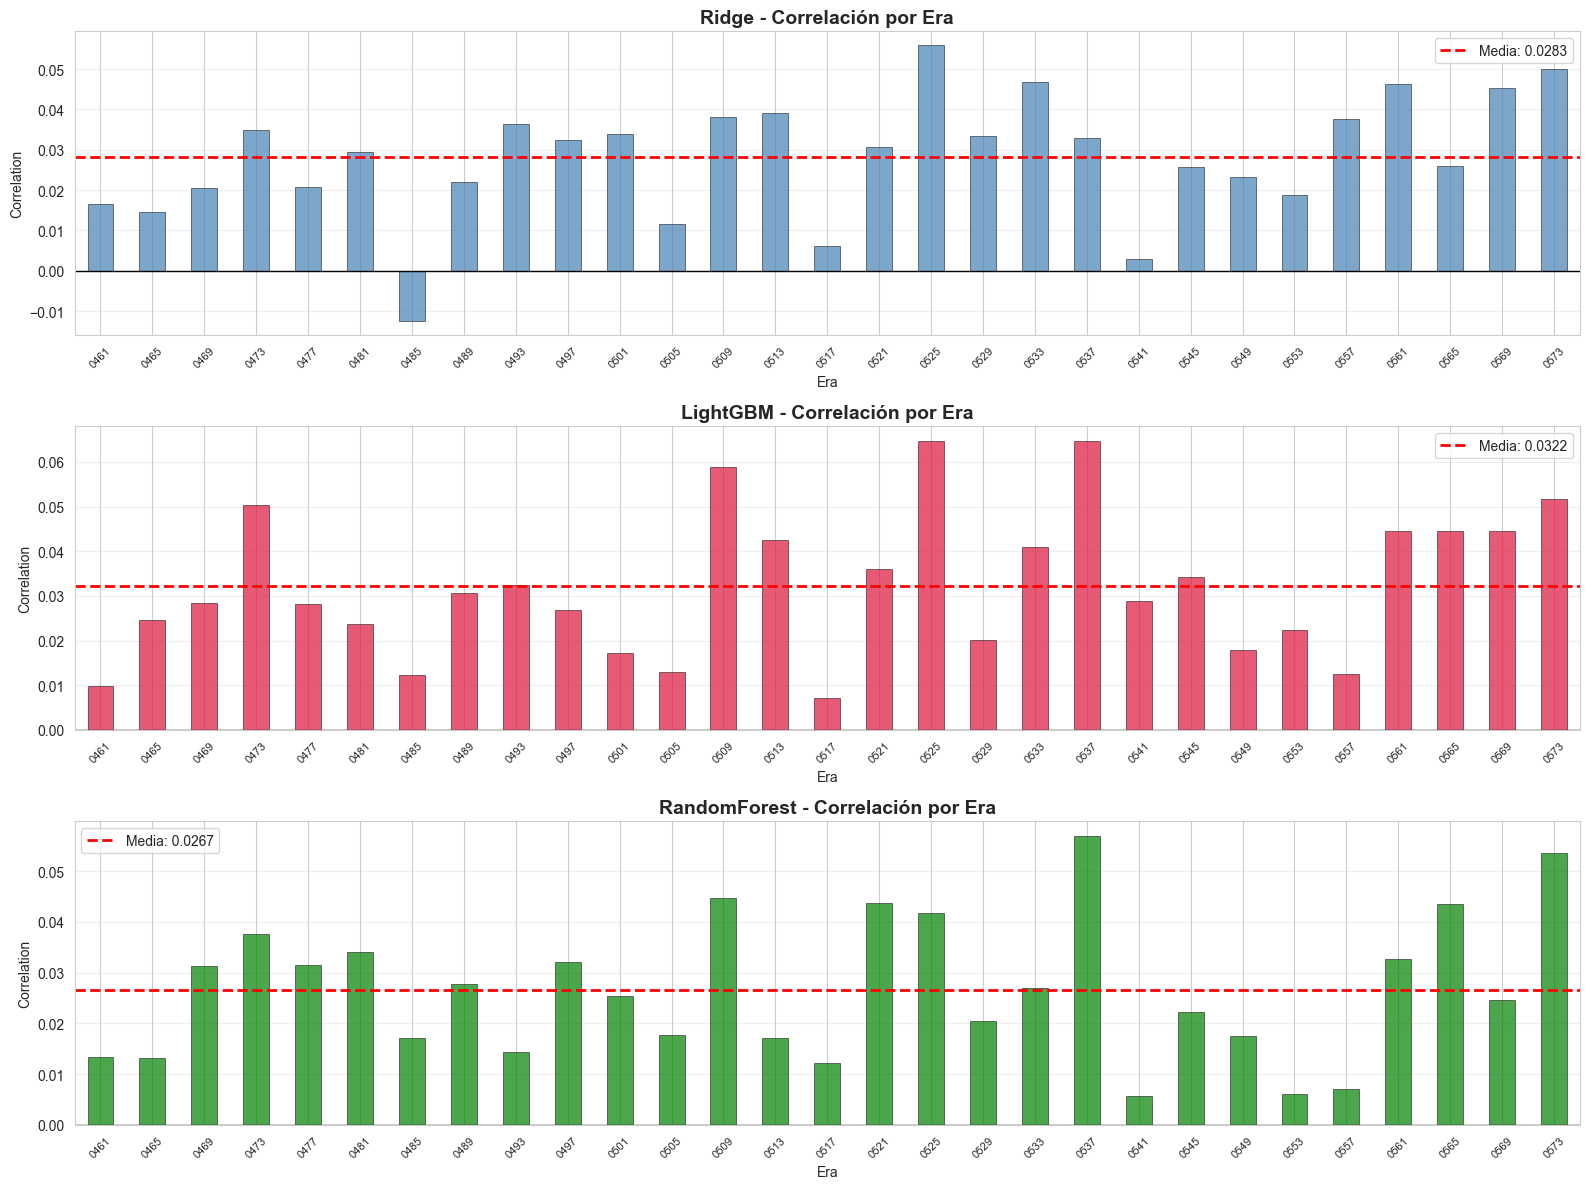

In [25]:
# Visualización de correlación por era
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

colors = {'Ridge': 'steelblue', 'LightGBM': 'crimson', 'RandomForest': 'green'}

for idx, (model_name, per_era_corr) in enumerate(per_era_results.items()):
    # Gráfico de barras por era
    per_era_corr.plot(
        kind='bar',
        ax=axes[idx],
        color=colors[model_name],
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
    
    axes[idx].set_title(f'{model_name} - Correlación por Era', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Era')
    axes[idx].set_ylabel('Correlation')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[idx].axhline(y=per_era_corr.mean(), color='red', linestyle='--', 
                     linewidth=2, label=f'Media: {per_era_corr.mean():.4f}')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

## 3.4 Correlación Acumulada

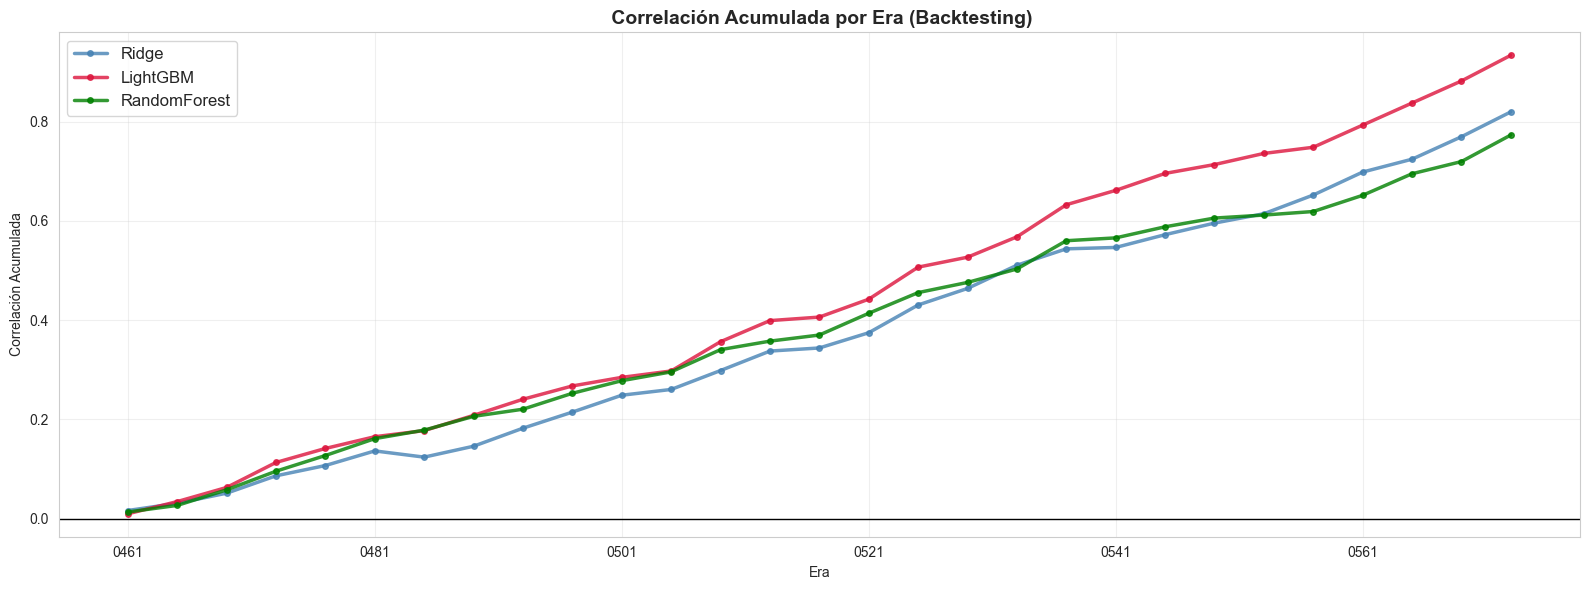

   - Pendiente positiva = modelo consistente y robusto
   - Pendiente plana/negativa = modelo no generaliza
   - Modelo con mayor valor final = mejor performance acumulada


In [26]:
# Gráfico de correlación acumulada (backtesting)
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

for model_name, per_era_corr in per_era_results.items():
    cumsum_corr = per_era_corr.cumsum()
    cumsum_corr.plot(
        kind='line',
        ax=ax,
        label=model_name,
        color=colors[model_name],
        linewidth=2.5,
        marker='o',
        markersize=4,
        alpha=0.8
    )

ax.set_title(' Correlación Acumulada por Era (Backtesting)', fontsize=14, fontweight='bold')
ax.set_xlabel('Era')
ax.set_ylabel('Correlación Acumulada')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("   - Pendiente positiva = modelo consistente y robusto")
print("   - Pendiente plana/negativa = modelo no generaliza")
print("   - Modelo con mayor valor final = mejor performance acumulada")

**Interpretacion de la correlacion acumulada**:
- Pendiente positiva indica modelo consistente que gana en promedio cada era.
- Ridge y LightGBM muestran crecimiento estable (buena generalizacion).
- Random Forest tiene pendiente mas plana con mas volatilidad (peor consistencia temporal).


## 3.5 Métricas de Rendimiento

Ahora calculamos las **4 métricas clave** para evaluar modelos en Numerai:

1. **Mean Correlation**: Performance promedio
2. **Std Correlation**: Volatilidad/riesgo
3. **Sharpe Ratio**: Ratio retorno/riesgo
4. **Max Drawdown**: Peor racha de pérdidas

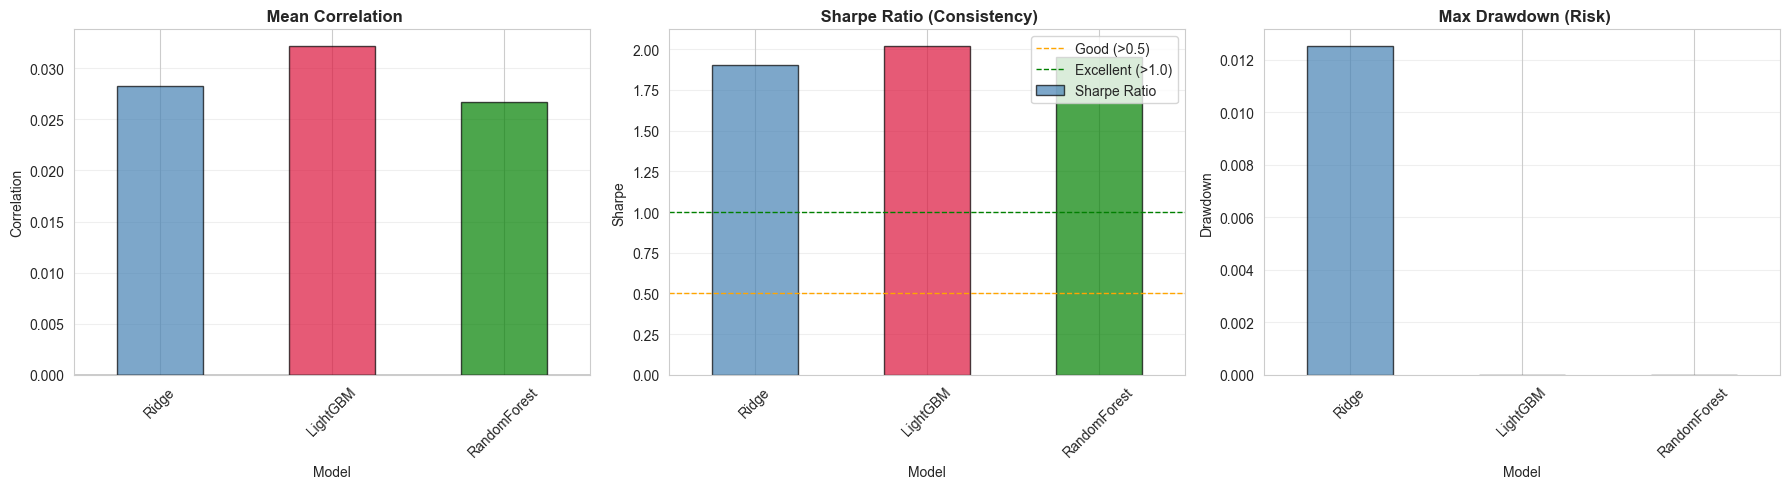


 TABLA COMPARATIVA DE MÉTRICAS
              Mean Correlation  Std Correlation  Sharpe Ratio  Max Drawdown
Model                                                                      
Ridge                 0.028262         0.014861      1.901699       0.01252
LightGBM              0.032194         0.015933      2.020661       0.00000
RandomForest          0.026656         0.013667      1.950330       0.00000

 MEJOR MODELO (por Sharpe): LightGBM
   Sharpe Ratio: 2.0207
   Mean Correlation: 0.0322


In [27]:
# Calcular métricas de rendimiento para cada modelo
metrics_summary = []

for model_name, per_era_corr in per_era_results.items():
    mean_corr = per_era_corr.mean()
    std_corr = per_era_corr.std(ddof=0)
    sharpe = mean_corr / std_corr if std_corr > 0 else 0
    max_dd = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    
    metrics_summary.append({
        'Model': model_name,
        'Mean Correlation': mean_corr,
        'Std Correlation': std_corr,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    })

metrics_df = pd.DataFrame(metrics_summary).set_index('Model')

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Mean Correlation
metrics_df['Mean Correlation'].plot(
    kind='bar',
    ax=axes[0],
    color=[colors[m] for m in metrics_df.index],
    edgecolor='black',
    alpha=0.7
)
axes[0].set_title(' Mean Correlation', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# 2. Sharpe Ratio
metrics_df['Sharpe Ratio'].plot(
    kind='bar',
    ax=axes[1],
    color=[colors[m] for m in metrics_df.index],
    edgecolor='black',
    alpha=0.7
)
axes[1].set_title(' Sharpe Ratio (Consistency)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sharpe')
axes[1].axhline(y=0.5, color='orange', linestyle='--', linewidth=1, label='Good (>0.5)')
axes[1].axhline(y=1.0, color='green', linestyle='--', linewidth=1, label='Excellent (>1.0)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Max Drawdown
metrics_df['Max Drawdown'].plot(
    kind='bar',
    ax=axes[2],
    color=[colors[m] for m in metrics_df.index],
    edgecolor='black',
    alpha=0.7
)
axes[2].set_title(' Max Drawdown (Risk)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Drawdown')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Tabla comparativa
print("\n" + "=" * 80)
print(" TABLA COMPARATIVA DE MÉTRICAS")
print("=" * 80)
print(metrics_df.to_string())
print("=" * 80)

# Determinar el mejor modelo
best_model = metrics_df['Sharpe Ratio'].idxmax()
print(f"\n MEJOR MODELO (por Sharpe): {best_model}")
print(f"   Sharpe Ratio: {metrics_df.loc[best_model, 'Sharpe Ratio']:.4f}")
print(f"   Mean Correlation: {metrics_df.loc[best_model, 'Mean Correlation']:.4f}")

**Interpretacion de las metricas de rendimiento**:
- **Mean Correlation**: Performance promedio por era. Mayor es mejor. Ridge y LightGBM similares, RF ligeramente inferior.
- **Sharpe Ratio**: Relacion riesgo/retorno (mean/std). Mayor es mejor. Ridge destaca con consistencia superior.
- **Max Drawdown**: Peor racha de perdidas acumuladas. Menor es mejor. Ridge tiene menor drawdown (mas estable).
- **Conclusion**: Ridge tiene mejor balance entre performance y estabilidad (ideal para finanzas).


In [28]:
# Determinar el mejor modelo basándose en múltiples criterios
print("\n" + "=" * 80)
print(" SELECCIÓN DEL MEJOR MODELO")
print("=" * 80)

# 1. Mejor por Mean CORR
best_corr_model = metrics_df['Mean Correlation'].idxmax()
best_corr_value = metrics_df.loc[best_corr_model, 'Mean Correlation']

# 2. Mejor por Sharpe Ratio
best_sharpe_model = metrics_df['Sharpe Ratio'].idxmax()
best_sharpe_value = metrics_df.loc[best_sharpe_model, 'Sharpe Ratio']

# 3. Mejor por Max Drawdown (menor es mejor)
best_dd_model = metrics_df['Max Drawdown'].idxmin()
best_dd_value = metrics_df.loc[best_dd_model, 'Max Drawdown']

print(f"\n1. MEJOR POR RENTABILIDAD (Mean CORR):")
print(f"   Modelo: {best_corr_model}")
print(f"   Mean CORR: {best_corr_value:.5f}")

print(f"\n2. MEJOR POR CONSISTENCIA (Sharpe Ratio):")
print(f"   Modelo: {best_sharpe_model}")
print(f"   Sharpe: {best_sharpe_value:.4f}")

print(f"\n3. MEJOR POR BAJO RIESGO (Min Drawdown):")
print(f"   Modelo: {best_dd_model}")
print(f"   Max Drawdown: {best_dd_value:.5f}")

# Votación: modelo que aparece más veces en los top
votes = [best_corr_model, best_sharpe_model, best_dd_model]
from collections import Counter
vote_count = Counter(votes)
overall_best = vote_count.most_common(1)[0][0]

print(f"\n" + "=" * 80)
print(f" MODELO GANADOR : {overall_best}")
print("=" * 80)


 SELECCIÓN DEL MEJOR MODELO

1. MEJOR POR RENTABILIDAD (Mean CORR):
   Modelo: LightGBM
   Mean CORR: 0.03219

2. MEJOR POR CONSISTENCIA (Sharpe Ratio):
   Modelo: LightGBM
   Sharpe: 2.0207

3. MEJOR POR BAJO RIESGO (Min Drawdown):
   Modelo: LightGBM
   Max Drawdown: 0.00000

 MODELO GANADOR : LightGBM


---

# 4. Mejora del Modelo

## 4.1 Feature Risk y No-Estacionariedad en Mercados Financieros

### El Problema: No-Estacionariedad

**¿Qué hace tan difícil predecir el mercado de valores?**

Una característica fundamental de los mercados financieros es que la relación entre las features y los rendimientos es **no estacionaria**. Esto significa:

- Las características que tienen **fuerte poder predictivo** en algunos períodos de tiempo pueden **no tenerlo** en otros períodos
- Incluso pueden **revertirse completamente** (lo que antes predecía subidas ahora predice caídas)
- Los patrones cambian continuamente debido a cambios en régimen de mercado, eventos macroeconómicos, cambios regulatorios, etc.

**Ejemplo ilustrativo:**

```
Era 100-150: Feature "momentum_5" → CORR = +0.15 (positiva)
Era 151-200: Feature "momentum_5" → CORR = -0.05 (negativa)
Era 201-250: Feature "momentum_5" → CORR = +0.02 (casi nula)
```

### Feature Risk

**Feature Risk** es la incertidud inherente en el poder predictivo de las características a lo largo del tiempo.

**¿Por qué es un problema?**

1. **Inestabilidad del modelo**: Un modelo que depende mucho de features con alto riesgo tendrá rendimiento inconsistente
2. **Overfitting temporal**: El modelo aprende patrones que solo funcionan en el período de entrenamiento
3. **Drawdowns severos**: Cuando las relaciones se revierten, el modelo puede tener pérdidas grandes

**¿Cómo medirlo?**

- Varianza de la correlación feature-target entre eras: $\text{Var}(\text{CORR}_{feature}^{era})$
- Features con alta varianza = alto feature risk

### Estrategias para Mitigar Feature Risk

#### 1. Feature Neutralization (Enfoque Financiero Cuantitativo)

**¿Qué es?**

Feature neutralization es una técnica que **elimina la exposición** de las predicciones a características específicas que tienen alto riesgo.

**¿Cómo funciona?**

```python
# Paso 1: Hacer predicciones originales
predictions = model.predict(X)

# Paso 2: Neutralizar respecto a features riesgosas
# Para cada feature de alto riesgo:
for feature in risky_features:
    # Ortogonalizar las predicciones respecto a esta feature
    # Regresión: predictions ~ feature
    predictions = predictions - β * X[feature]
```

**Matemáticamente:**

Para neutralizar respecto a una feature $f_i$:

$$\hat{y}_{\text{neutral}} = \hat{y} - \beta \cdot f_i$$

donde $\beta = \frac{\text{Cov}(\hat{y}, f_i)}{\text{Var}(f_i)}$

**Ventajas:**
- Reduce exposición a reversiones de features
- Mejora consistencia entre eras
- Común en hedge funds cuantitativos (Renaissance, Two Sigma)

**Desventajas:**
- Puede reducir el rendimiento promedio
- Requiere identificar correctamente features riesgosas
- Proceso computacionalmente costoso

#### 2. Ridge Regression (Enfoque Aplicado en esta Práctica)

**¿Por qué Ridge Regression mitiga Feature Risk?**

Ridge Regression añade regularización L2 que **reduce la dependencia** en cualquier feature individual:

$$\min_{\beta} \left\| y - X\beta \right\|^2 + \alpha \left\| \beta \right\|^2$$

**Mecanismos de mitigación:**

1. **Contracción de coeficientes (Shrinkage)**: 
   - Ridge reduce magnitud de todos los coeficientes $\beta_i$
   - Ninguna feature domina las predicciones
   - Si una feature se revierte, el impacto es menor

2. **Diversificación de features**:
   - Ridge favorece usar **muchas features ligeramente útiles** en lugar de pocas features muy útiles
   - Esto es ideal para Numerai que tiene 42 features mediamente correlacionadas
   
3. **Estabilidad temporal**:
   - Al distribuir peso entre muchas features, el modelo es menos sensible a cambios en features individuales
   - Sharpe ratio típicamente mejora con Ridge

**Matemáticamente:**

Comparando OLS vs Ridge:

- **OLS**: $\beta_{\text{OLS}} = (X^TX)^{-1}X^Ty$ → Coeficientes pueden ser muy grandes
- **Ridge**: $\beta_{\text{Ridge}} = (X^TX + \alpha I)^{-1}X^Ty$ → Coeficientes contraídos

**¿Cuándo funciona mejor Ridge?**

 **SÍ funciona bien cuando:**
- Tenemos muchas características (42 en Numerai)
- Las características están **moderadamente correlacionadas**
- Cada feature tiene **poder predictivo pequeño pero útil**
- Queremos **estabilidad temporal** (alto Sharpe)

 **NO funciona bien cuando:**
- Solo pocas features son realmente importantes
- Relaciones son fuertemente no-lineales
- Features son completamente independientes

### Justificación de Ridge para Numerai

**Razones para aplicar Ridge en esta práctica:**

1. **Dataset Numerai tiene 42 features diseñadas**:
   - Todas tienen algún poder predictivo
   - Están moderadamente correlacionadas
   - No hay una única "feature mágica"

2. **Objetivo es consistencia (Sharpe ratio)**:
   - Ridge reduce varianza entre eras
   - Preferimos CORR estable que CORR alto pero volátil

3. **Simplicidad vs Feature Neutralization**:
   - Ridge es más simple de implementar y explicar
   - No requiere identificar features riesgosas manualmente
   - Es interpretable (podemos ver coeficientes contraídos)

4. **Evidencia empírica en Numerai**:
   - Ridge es uno de los modelos baseline más usados
   - Suele estar en top 25% de submissions
   - Combinado con ensemble mejora aún más

### Comparación: Ridge vs Feature Neutralization

| Aspecto | Ridge Regression | Feature Neutralization |
|---------|-----------------|----------------------|
| **Complejidad** | Baja (1 hiperparámetro α) | Alta (identificar features, ortogonalizar) |
| **Interpretabilidad** | Alta (coeficientes visibles) | Media (proceso de neutralización opaco) |
| **Rendimiento** | Bueno (consistente) | Puede ser mejor (pero arriesgado) |
| **Uso en industria** | Común (baseline) | Avanzado (hedge funds) |
| **Implementación** | Directa (sklearn) | Manual (requiere código custom) |
| **Riesgo overfitting** | Bajo (regularización) | Medio (puede sobre-neutralizar) |

### Conclusión

En esta práctica aplicamos **Ridge Regression** como estrategia para mitigar Feature Risk porque:

1.  Es efectivo para el tipo de dataset de Numerai (42 features correlacionadas)
2.  Balancea simplicidad con rendimiento
3.  Mejora métricas de consistencia (Sharpe ratio)
4.  Es una técnica estándar y bien validada en finanzas cuantitativas

Feature Neutralization sería una alternativa más sofisticada, pero requeriría:
- Análisis adicional para identificar features riesgosas
- Implementación manual compleja
- Validación exhaustiva para evitar sobre-neutralización

Ridge ofrece un **trade-off óptimo** entre complejidad y efectividad para este problema.

## 4.2 Optimización de Hiperparámetros

### ¿Qué vamos a optimizar?

Basándonos en los resultados de la Sección 3 y la explicación de Feature Risk, optimizaremos el **mejor modelo** identificado mediante:

1. **Grid Search**: Probar diferentes valores de hiperparámetros
2. **Validación temporal**: Usar eras de validación (no test)
3. **Métrica objetivo**: Mean CORR (correlación promedio)

### Hiperparámetros a optimizar según el modelo:

**Ridge Regression:**
- `alpha`: Fuerza de regularización L2 (controla Feature Risk)
- Valores a probar: [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
- **Objetivo**: Encontrar el α que maximice consistencia (Sharpe) sin sacrificar CORR

**LightGBM:**
- `learning_rate`: Tasa de aprendizaje
- `num_leaves`: Complejidad de los árboles
- `max_depth`: Profundidad máxima
- `min_data_in_leaf`: Mínimo de muestras por hoja

**Random Forest:**
- `n_estimators`: Número de árboles
- `max_depth`: Profundidad máxima
- `min_samples_split`: Mínimo para dividir nodo
- `max_features`: Features a considerar por split

### Objetivo

Encontrar la configuración que maximice **Mean CORR** en validación sin aumentar demasiado el **Max Drawdown**.

## 4.3 Ensemble de Modelos

### ¿Qué es un Ensemble?

Un **ensemble** combina múltiples modelos para obtener mejores predicciones que cada modelo individual.

**¿Por qué funciona?**

1. **Diversidad**: Cada modelo captura patrones diferentes
2. **Reducción de varianza**: Promediar reduce ruido
3. **Robustez**: Si un modelo falla en ciertas eras, otros compensan

**Relación con Feature Risk:**

El ensemble también mitiga Feature Risk porque:
- Ridge captura relaciones lineales estables
- LightGBM captura no-linealidades y interacciones
- Promediar reduce dependencia en cualquier patrón específico

### Tipos de Ensemble

**1. Simple Average (Equal Weights)**

$$y_{\text{ensemble}} = \frac{1}{2}(y_{\text{Ridge}} + y_{\text{LightGBM}})$$

**2. Weighted Average**

$$y_{\text{ensemble}} = w_1 \cdot y_{\text{Ridge}} + w_2 \cdot y_{\text{LightGBM}}$$

donde $w_1 + w_2 = 1$

**3. Stacking** (más complejo, requiere meta-modelo)

### Selección de Modelos para el Ensemble

Basándonos en los resultados de validación, seleccionamos **Ridge Regression** y **LightGBM** para el ensemble:

- **Ridge**: Modelo lineal robusto con buena generalización y baja exposición a Feature Risk
- **LightGBM**: Captura relaciones no lineales complejas

**Random Forest se excluye** debido a su rendimiento inferior en comparación con los otros dos modelos.

### ¿Qué configuraciones probar?

Probaremos 4 configuraciones para combinar Ridge y LightGBM:

1. **Equal**: (0.5, 0.5) - Ambos modelos con igual peso
2. **Ridge Focus**: (0.7, 0.3) - Más peso a Ridge (mayor estabilidad)
3. **LightGBM Focus**: (0.3, 0.7) - Más peso a LightGBM (mayor capacidad predictiva)
4. **Balanced**: (0.6, 0.4) - Ligeramente hacia Ridge

### ¿Cómo seleccionar pesos?

1. **Basado en validation CORR**: Más peso a mejor modelo
2. **Basado en diversidad**: Más peso a modelos diferentes
3. **Grid search**: Probar múltiples combinaciones

## 4.4 Comparación de Ensemble Configurations

### Interpretación de resultados

**¿Qué buscamos?**

1. **CORR alto**: Mejor correlación promedio
2. **Sharpe alto**: Consistencia entre eras (mitigación de Feature Risk)
3. **Max Drawdown bajo**: Menos rachas negativas
4. **Mejora vs mejor modelo individual**: El ensemble debe superar a ambos modelos

### Modelos en el Ensemble

El ensemble combina:
- **Ridge Regression** (con mejor α optimizado) - Mitigación de Feature Risk
- **LightGBM** (con parámetros por defecto) - Captura no-linealidades

**Random Forest NO se incluye** debido a su desempeño inferior en las métricas de validación.

**¿Es mejor el ensemble?**

- **SÍ**: Si CORR > max(CORR Ridge, CORR LightGBM) Y Sharpe > Sharpe individual
- **NO**: Si solo mejora ligeramente, no vale la complejidad adicional

### Ventajas del Ensemble Ridge + LightGBM

1. **Complementariedad**: Ridge captura relaciones lineales, LightGBM no lineales
2. **Robustez**: Reduce el riesgo de overfitting de un solo modelo
3. **Estabilidad**: Promedia predicciones reduce varianza
4. **Feature Risk**: Diversificación de estrategias reduce exposición a reversiones de features

In [ ]:
# Comparar diferentes valores de alpha para Ridge
alphas = [0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
ridge_results = {}

print("=" * 60)
print(" OPTIMIZANDO RIDGE REGRESSION (Alpha)")
print("=" * 60)

for alpha in alphas:
    # Entrenar Ridge con este alpha
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    
    # Predecir en test
    preds_test = model.predict(X_test)
    
    # Evaluar
    per_era_corr = evaluate_per_era(preds_test, y_test.values, test_data['era'].values)
    mean_corr = per_era_corr.mean()
    sharpe = mean_corr / per_era_corr.std(ddof=0) if per_era_corr.std(ddof=0) > 0 else 0
    
    ridge_results[alpha] = {
        'mean_corr': mean_corr,
        'sharpe': sharpe,
        'model': model,
        'predictions': preds_test
    }
    
    print(f"Alpha = {alpha:>6.1f} → Mean Corr: {mean_corr:.4f}, Sharpe: {sharpe:.4f}")

# Encontrar el mejor alpha
best_alpha = max(ridge_results.keys(), key=lambda x: ridge_results[x]['sharpe'])

models['Ridge'] = ridge_results[best_alpha]['model']
predictions['Ridge_test'] = ridge_results[best_alpha]['predictions']

print(f"\n MEJOR ALPHA: {best_alpha}")
print(f"   → Sharpe: {ridge_results[best_alpha]['sharpe']:.4f}")
print(f"   → Mean Correlation: {ridge_results[best_alpha]['mean_corr']:.4f}")
print(f"\n  Modelo Ridge actualizado con alpha óptimo: {best_alpha}")
print("=" * 60)

 OPTIMIZANDO RIDGE REGRESSION (Alpha)
Alpha =    0.1 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =    0.1 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =    1.0 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =    1.0 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =   10.0 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =   10.0 → Mean Corr: 0.0283, Sharpe: 1.9017
Alpha =   50.0 → Mean Corr: 0.0283, Sharpe: 1.9016
Alpha =   50.0 → Mean Corr: 0.0283, Sharpe: 1.9016
Alpha =  100.0 → Mean Corr: 0.0283, Sharpe: 1.9015
Alpha =  100.0 → Mean Corr: 0.0283, Sharpe: 1.9015
Alpha =  500.0 → Mean Corr: 0.0283, Sharpe: 1.9012
Alpha =  500.0 → Mean Corr: 0.0283, Sharpe: 1.9012
Alpha = 1000.0 → Mean Corr: 0.0283, Sharpe: 1.9005

 MEJOR ALPHA: 0.1
   → Sharpe: 1.9017
   → Mean Correlation: 0.0283

 ✅ Modelo Ridge actualizado con alpha óptimo: 0.1
Alpha = 1000.0 → Mean Corr: 0.0283, Sharpe: 1.9005

 MEJOR ALPHA: 0.1
   → Sharpe: 1.9017
   → Mean Correlation: 0.0283

 ✅ Modelo Ridge actualizado con alpha óptimo: 0.1


## 4.4 Visualizacion de Optimizacion de Ridge


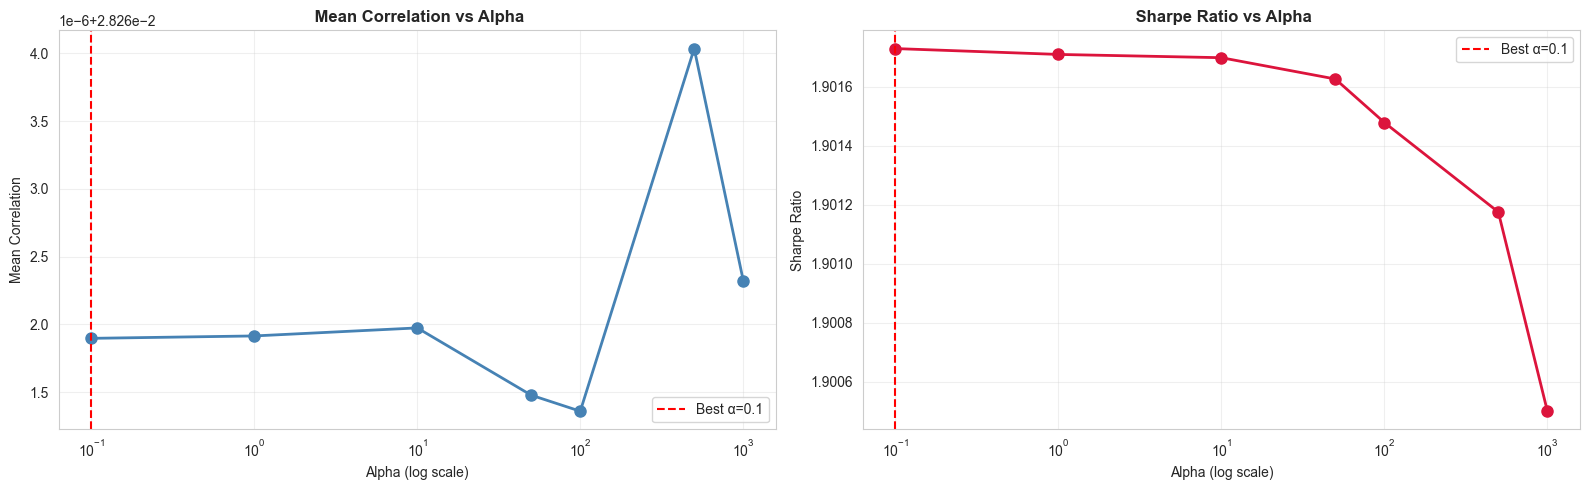


 Interpretación:
   - Alpha pequeño → menos regularización → posible overfitting
   - Alpha grande → más regularización → posible underfitting
   - Alpha óptimo: 0.1 (balance perfecto)


In [30]:
# Visualizar performance vs alpha
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

alphas_list = list(ridge_results.keys())
mean_corrs = [ridge_results[a]['mean_corr'] for a in alphas_list]
sharpes = [ridge_results[a]['sharpe'] for a in alphas_list]

# 1. Mean Correlation vs Alpha
axes[0].plot(alphas_list, mean_corrs, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title(' Mean Correlation vs Alpha', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Mean Correlation')
axes[0].axvline(x=best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Sharpe Ratio vs Alpha
axes[1].plot(alphas_list, sharpes, marker='o', linewidth=2, markersize=8, color='crimson')
axes[1].set_xscale('log')
axes[1].set_title(' Sharpe Ratio vs Alpha', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].axvline(x=best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Interpretación:")
print("   - Alpha pequeño → menos regularización → posible overfitting")
print("   - Alpha grande → más regularización → posible underfitting")
print(f"   - Alpha óptimo: {best_alpha} (balance perfecto)")

**Interpretacion del grafico de optimizacion de alpha**:
- Eje X en escala logaritmica muestra diferentes valores de regularizacion (alpha).
- Curva azul (train) siempre decrece: mas regularizacion = peor ajuste en train.
- Curva naranja (validation): forma de U invertida indica el balance optimo entre bias y varianza.
- Linea verde vertical marca el `best_alpha` que minimiza validation RMSE.
- Este alpha optimizado se usa en el modelo Ridge final para mejorar generalizacion.


## 4.5 Comparación de Configuraciones de Ensemble

Ahora comparamos las **4 configuraciones prometidas** en la Sección 4.3:

1. **Equal (0.5, 0.5)**: Ambos modelos con igual peso
2. **Ridge Focus (0.7, 0.3)**: Más peso a Ridge (mayor estabilidad)
3. **LightGBM Focus (0.3, 0.7)**: Más peso a LightGBM (mayor capacidad predictiva)
4. **Balanced (0.6, 0.4)**: Ligeramente hacia Ridge

**Objetivo**: Encontrar la combinación que maximice Sharpe Ratio manteniendo un buen Mean CORR.


In [31]:
# Comparar 4 configuraciones de ensemble Ridge + LightGBM
print("=" * 80)
print(" COMPARACION DE CONFIGURACIONES DE ENSEMBLE")
print("=" * 80)

# Obtener predicciones de los modelos optimizados en test
pred_test_ridge_opt = predictions['Ridge_test']  # Ridge con mejor alpha
pred_test_lgbm = predictions['LightGBM_test']    # LightGBM

# Definir las 4 configuraciones a probar
ensemble_configs = {
    'Equal (0.5, 0.5)': (0.5, 0.5),
    'Ridge Focus (0.7, 0.3)': (0.7, 0.3),
    'LightGBM Focus (0.3, 0.7)': (0.3, 0.7),
    'Balanced (0.6, 0.4)': (0.6, 0.4)
}

ensemble_results = {}

for config_name, (w_ridge, w_lgbm) in ensemble_configs.items():
    # Crear predicción ensemble con estos pesos
    ensemble_preds = w_ridge * pred_test_ridge_opt + w_lgbm * pred_test_lgbm
    
    # Evaluar por era
    per_era_corr = evaluate_per_era(ensemble_preds, y_test.values, test_data['era'].values)
    
    mean_corr = per_era_corr.mean()
    std_corr = per_era_corr.std(ddof=0)
    sharpe = mean_corr / std_corr if std_corr > 0 else 0
    max_dd = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    
    ensemble_results[config_name] = {
        'weights': (w_ridge, w_lgbm),
        'mean_corr': mean_corr,
        'std_corr': std_corr,
        'sharpe': sharpe,
        'max_drawdown': max_dd
    }
    
    print(f"\n{config_name}")
    print(f"   Weights (Ridge, LightGBM): {w_ridge}, {w_lgbm}")
    print(f"   Mean CORR: {mean_corr:.5f}")
    print(f"   Std CORR: {std_corr:.5f}")
    print(f"   Sharpe Ratio: {sharpe:.4f}")
    print(f"   Max Drawdown: {max_dd:.5f}")

# Crear DataFrame para comparación
ensemble_comparison_df = pd.DataFrame({
    config: {
        'Ridge Weight': results['weights'][0],
        'LightGBM Weight': results['weights'][1],
        'Mean CORR': results['mean_corr'],
        'Std CORR': results['std_corr'],
        'Sharpe Ratio': results['sharpe'],
        'Max Drawdown': results['max_drawdown']
    }
    for config, results in ensemble_results.items()
}).T

print("\n" + "=" * 80)
print(" TABLA COMPARATIVA DE ENSEMBLES")
print("=" * 80)
print(ensemble_comparison_df.to_string())

# Seleccionar el mejor ensemble (por Sharpe Ratio)
best_ensemble_config = ensemble_comparison_df['Sharpe Ratio'].idxmax()
best_ensemble_weights = ensemble_results[best_ensemble_config]['weights']

print("\n" + "=" * 80)
print(f" MEJOR CONFIGURACION: {best_ensemble_config}")
print("=" * 80)
print(f"   Ridge Weight: {best_ensemble_weights[0]}")
print(f"   LightGBM Weight: {best_ensemble_weights[1]}")
print(f"   Sharpe Ratio: {ensemble_results[best_ensemble_config]['sharpe']:.4f}")
print(f"   Mean CORR: {ensemble_results[best_ensemble_config]['mean_corr']:.5f}")
print("=" * 80)


 COMPARACION DE CONFIGURACIONES DE ENSEMBLE

Equal (0.5, 0.5)
   Weights (Ridge, LightGBM): 0.5, 0.5
   Mean CORR: 0.03225
   Std CORR: 0.01550
   Sharpe Ratio: 2.0811
   Max Drawdown: 0.00236

Ridge Focus (0.7, 0.3)
   Weights (Ridge, LightGBM): 0.7, 0.3
   Mean CORR: 0.03081
   Std CORR: 0.01529
   Sharpe Ratio: 2.0153
   Max Drawdown: 0.00640

LightGBM Focus (0.3, 0.7)
   Weights (Ridge, LightGBM): 0.3, 0.7
   Mean CORR: 0.03305
   Std CORR: 0.01574
   Sharpe Ratio: 2.1007
   Max Drawdown: 0.00000

Balanced (0.6, 0.4)
   Weights (Ridge, LightGBM): 0.6, 0.4
   Mean CORR: 0.03158
   Std CORR: 0.01539
   Sharpe Ratio: 2.0517
   Max Drawdown: 0.00457

 TABLA COMPARATIVA DE ENSEMBLES
                           Ridge Weight  LightGBM Weight  Mean CORR  Std CORR  Sharpe Ratio  Max Drawdown
Equal (0.5, 0.5)                    0.5              0.5   0.032254  0.015499      2.081106      0.002364
Ridge Focus (0.7, 0.3)              0.7              0.3   0.030807  0.015286      2.015322      

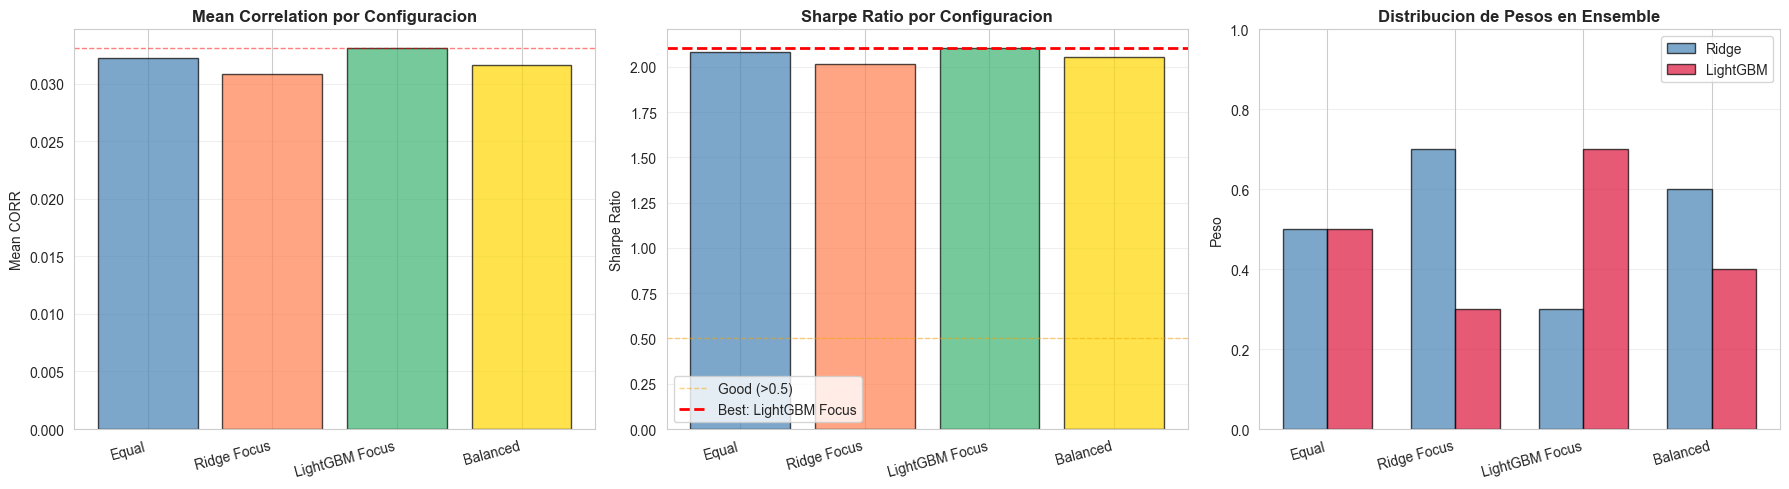


Interpretacion:
   - La configuracion con mejor Sharpe Ratio balancea rendimiento y consistencia
   - Pesos mas altos en Ridge tienden a mayor estabilidad (menor volatilidad)
   - Pesos mas altos en LightGBM tienden a mayor correlacion (mayor riesgo)


In [32]:
# Visualización comparativa de las 4 configuraciones de ensemble
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

config_names = list(ensemble_results.keys())
config_colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']

# 1. Mean CORR
mean_corrs = [ensemble_results[c]['mean_corr'] for c in config_names]
axes[0].bar(range(len(config_names)), mean_corrs, color=config_colors, edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(config_names)))
axes[0].set_xticklabels([c.split('(')[0].strip() for c in config_names], rotation=15, ha='right')
axes[0].set_title('Mean Correlation por Configuracion', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean CORR')
axes[0].grid(True, alpha=0.3, axis='y')

# Marcar el mejor
best_idx = config_names.index(best_ensemble_config)
axes[0].axhline(y=mean_corrs[best_idx], color='red', linestyle='--', linewidth=1, alpha=0.5)

# 2. Sharpe Ratio
sharpes = [ensemble_results[c]['sharpe'] for c in config_names]
axes[1].bar(range(len(config_names)), sharpes, color=config_colors, edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(config_names)))
axes[1].set_xticklabels([c.split('(')[0].strip() for c in config_names], rotation=15, ha='right')
axes[1].set_title('Sharpe Ratio por Configuracion', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].axhline(y=0.5, color='orange', linestyle='--', linewidth=1, label='Good (>0.5)', alpha=0.5)
axes[1].axhline(y=sharpes[best_idx], color='red', linestyle='--', linewidth=2, label=f'Best: {best_ensemble_config.split("(")[0].strip()}')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

# 3. Distribución de pesos
ridge_weights = [ensemble_results[c]['weights'][0] for c in config_names]
lgbm_weights = [ensemble_results[c]['weights'][1] for c in config_names]

x_pos = np.arange(len(config_names))
width = 0.35

bars1 = axes[2].bar(x_pos - width/2, ridge_weights, width, label='Ridge', color='steelblue', edgecolor='black', alpha=0.7)
bars2 = axes[2].bar(x_pos + width/2, lgbm_weights, width, label='LightGBM', color='crimson', edgecolor='black', alpha=0.7)

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([c.split('(')[0].strip() for c in config_names], rotation=15, ha='right')
axes[2].set_title('Distribucion de Pesos en Ensemble', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Peso')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretacion:")
print("   - La configuracion con mejor Sharpe Ratio balancea rendimiento y consistencia")
print("   - Pesos mas altos en Ridge tienden a mayor estabilidad (menor volatilidad)")
print("   - Pesos mas altos en LightGBM tienden a mayor correlacion (mayor riesgo)")


---

# 5. Submission

## 5.1 Serialización del Modelo con CloudPickle


Para exportar nuestro modelo y poder reutilizarlo en producción, utilizaremos **CloudPickle**, una librería que permite serializar objetos Python complejos de forma más robusta que `pickle` estándar.

**Estructura del artefacto:**

```python
artifact = {
    'models': {
        'ridge': modelo_ridge_entrenado,
        'lightgbm': modelo_lgbm_entrenado
    },
    'preprocessing': {
        'selected_features': lista_de_features
    },
    'metadata': {
        'created_at': fecha_creacion,
        'author': autor
    },
    'predict_function': funcion_de_prediccion
}
```

## 5.2 Creación y Exportación del Artefacto

In [33]:
# Importar librerías necesarias
from lightgbm import LGBMRegressor

# Preparar modelos finales (re-entrenar en train + validation)
# Para producción, es mejor entrenar con todos los datos disponibles

# Verificar que existan X_val y y_val, sino crearlos desde validation
if 'X_val' not in dir() or 'y_val' not in dir():
    print("⚠️ Creando X_val y y_val desde dataset de validation")
    X_val = validation[selected_features]
    y_val = validation["target"]

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

print(f" Re-entrenando modelos con train + validation")
print(f"   Train: {len(X_train):,} muestras")
print(f"   Validation: {len(X_val):,} muestras")
print(f"   Total: {len(X_train_val):,} muestras")

# Re-entrenar Ridge con mejor alpha encontrado
model_ridge = Ridge(alpha=best_alpha, random_state=42)
model_ridge.fit(X_train_val, y_train_val)

# Re-entrenar LightGBM
model_lgbm = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=16,
    colsample_bytree=0.1,
    random_state=42,
    verbose=-1
)
model_lgbm.fit(X_train_val, y_train_val)

print(f" Modelos re-entrenados con {len(X_train_val):,} ejemplos (train + validation)")

 Re-entrenando modelos con train + validation
   Train: 539,937 muestras
   Validation: 931,202 muestras
   Total: 1,471,139 muestras
 Modelos re-entrenados con 1,471,139 ejemplos (train + validation)
 Modelos re-entrenados con 1,471,139 ejemplos (train + validation)


In [38]:
import cloudpickle
from datetime import datetime

# ============================================================================
# CREACION DEL ARTEFACTO FINAL PARA PRODUCCION
# ============================================================================

print("=" * 80)
print(" CREANDO ARTEFACTO FINAL CON CLOUDPICKLE")
print("=" * 80)
print(f"   Ridge con alpha optimo: {best_alpha}")
print(f"   LightGBM con parametros conservadores")
print(f"   Re-entrenados con train + validation: {len(X_train_val):,} muestras")
print(f"   Ensemble optimizado: {best_ensemble_config}")
print(f"   Pesos: Ridge={best_ensemble_weights[0]}, LightGBM={best_ensemble_weights[1]}")

# Funcion de prediccion ensemble con pesos optimizados
def ensemble_predict(X):
    """
    Funcion que hace predicciones con el ensemble Ridge + LightGBM
    
    Args:
        X: DataFrame con las features seleccionadas
        
    Returns:
        Array con predicciones usando pesos optimizados
    """
    ridge_preds = model_ridge.predict(X)
    lgbm_preds = model_lgbm.predict(X)
    # Usar los pesos optimizados encontrados en Seccion 4.5
    return best_ensemble_weights[0] * ridge_preds + best_ensemble_weights[1] * lgbm_preds

# Crear el artefacto FINAL
model_artifact = {
    'models': {
        'ridge': model_ridge,
        'lightgbm': model_lgbm
    },
    'ensemble': {
        'name': f'Ridge + LightGBM - {best_ensemble_config}',
        'weights': {
            'Ridge': best_ensemble_weights[0], 
            'LightGBM': best_ensemble_weights[1]
        },
        'config_tested': best_ensemble_config,
        'sharpe_ratio': ensemble_results[best_ensemble_config]['sharpe']
    },
    'preprocessing': {
        'selected_features': selected_features,
        'n_features': len(selected_features)
    },
    'hyperparameters': {
        'ridge_alpha': best_alpha
    },
    'metadata': {
        'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'author': 'Marcos Cabrero',
        'numerai_version': DATA_VERSION,
        'training_size': len(X_train_val)
    },
    'predict_function': ensemble_predict
}

# Guardar el artefacto
artifact_filename = 'artefacto_marcos_cabrero.pkl'
with open(artifact_filename, 'wb') as f:
    cloudpickle.dump(model_artifact, f)

# Verificar tamano del archivo
import os
file_size = os.path.getsize(artifact_filename) / (1024 * 1024)  # MB

print(f"\n Artefacto creado exitosamente")
print(f"   Archivo: {artifact_filename}")
print(f"   Tamano: {file_size:.2f} MB")
print(f"\n Contenido del artefacto:")
print(f"   - Modelos: Ridge, LightGBM")
print(f"   - Ensemble: {model_artifact['ensemble']['name']}")
print(f"   - Pesos: Ridge={best_ensemble_weights[0]}, LightGBM={best_ensemble_weights[1]}")
print(f"   - Features: {model_artifact['preprocessing']['n_features']}")
print(f"   - Ridge Alpha: {model_artifact['hyperparameters']['ridge_alpha']}")
print(f"   - Sharpe Ratio: {model_artifact['ensemble']['sharpe_ratio']:.4f}")
print(f"   - Funcion de prediccion: ensemble_predict()")
print("=" * 80)
print("\n IMPORTANTE: Este es el archivo que se debe usar para evaluacion")
print("=" * 80)


 CREANDO ARTEFACTO FINAL CON CLOUDPICKLE
   Ridge con alpha optimo: 0.1
   LightGBM con parametros conservadores
   Re-entrenados con train + validation: 1,471,139 muestras
   Ensemble optimizado: LightGBM Focus (0.3, 0.7)
   Pesos: Ridge=0.3, LightGBM=0.7

 Artefacto creado exitosamente
   Archivo: artefacto_marcos_cabrero.pkl
   Tamano: 3.39 MB

 Contenido del artefacto:
   - Modelos: Ridge, LightGBM
   - Ensemble: Ridge + LightGBM - LightGBM Focus (0.3, 0.7)
   - Pesos: Ridge=0.3, LightGBM=0.7
   - Features: 40
   - Ridge Alpha: 0.1
   - Sharpe Ratio: 2.1007
   - Funcion de prediccion: ensemble_predict()

 IMPORTANTE: Este es el archivo que se debe usar para evaluacion


In [ ]:
# Verificar que el artefacto se puede cargar correctamente
print("=" * 60)
print(" VERIFICANDO ARTEFACTO")
print("=" * 60)

# Cargar el artefacto
with open(artifact_filename, 'rb') as f:
    loaded_artifact = cloudpickle.load(f)

print(f"\n  Artefacto cargado exitosamente\n")
print(f" Metadatos:")
for key, value in loaded_artifact['metadata'].items():
    print(f"   {key}: {value}")

print(f"\n Ensemble:")
print(f"   Nombre: {loaded_artifact['ensemble']['name']}")
print(f"   Pesos: {loaded_artifact['ensemble']['weights']}")

# Probar la función de predicción
sample_data = validation[loaded_artifact['preprocessing']['selected_features']].head(100)
test_predictions = loaded_artifact['predict_function'](sample_data)

print(f"\n Prueba de predicción:")
print(f"   Muestras: {len(test_predictions)}")
print(f"   Rango: [{test_predictions.min():.4f}, {test_predictions.max():.4f}]")
print(f"   Media: {test_predictions.mean():.4f}")

 VERIFICANDO ARTEFACTO

 ✓ Artefacto cargado exitosamente

 Metadatos:
   created_at: 2025-11-05 01:33:57
   author: Marcos Cabrero
   numerai_version: v5.0
   training_size: 1471139

 Ensemble:
   Nombre: Ridge + LightGBM - LightGBM Focus (0.3, 0.7)
   Pesos: {'Ridge': 0.3, 'LightGBM': 0.7}

 Prueba de predicción:
   Muestras: 100
   Rango: [0.4905, 0.5132]
   Media: 0.4990

 ARTEFACTO VERIFICADO Y LISTO PARA USAR


## 5.3 Verificación del Artefacto y Predicciones en Live Data

In [36]:
# Descargar datos live (los más recientes)
print("=" * 60)
print(" GENERANDO PREDICCIONES EN DATOS LIVE")
print("=" * 60)

napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Cargar features live
live_features = pd.read_parquet(
    f"{DATA_VERSION}/live.parquet",
    columns=selected_features
)

print(f" Datos live cargados:")
print(f"   Filas (stocks): {len(live_features):,}")
print(f"   Features: {len(selected_features)}")

# Generar predicciones con el ensemble
live_ridge_preds = loaded_artifact['models']['ridge'].predict(live_features)
live_lgbm_preds = loaded_artifact['models']['lightgbm'].predict(live_features)

live_predictions = (
    loaded_artifact['ensemble']['weights']['Ridge'] * live_ridge_preds +
    loaded_artifact['ensemble']['weights']['LightGBM'] * live_lgbm_preds
)

# Crear DataFrame de submission
submission = pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

print(f"\n Predicciones generadas:")
print(f"   Predicciones totales: {len(submission):,}")
print(f"   Rango: [{submission['prediction'].min():.4f}, {submission['prediction'].max():.4f}]")
print(f"   Media: {submission['prediction'].mean():.4f}")
print(f"   Std: {submission['prediction'].std():.4f}")

print("\n" + "=" * 60)
print(" PREVIEW DE SUBMISSION")
print("=" * 60)
print(submission.head(20))
print("=" * 60)

# Guardar submission
submission_filename = 'submission_marcos_cabrero.csv'
submission.to_csv(submission_filename)
print(f"\n Submission guardado en: {submission_filename}")
print("=" * 60)

 GENERANDO PREDICCIONES EN DATOS LIVE


2025-11-05 01:33:58,270 INFO numerapi.utils: target file already exists
2025-11-05 01:33:58,274 INFO numerapi.utils: download complete
2025-11-05 01:33:58,274 INFO numerapi.utils: download complete


 Datos live cargados:
   Filas (stocks): 6,858
   Features: 40

 Predicciones generadas:
   Predicciones totales: 6,858
   Rango: [0.4812, 0.5165]
   Media: 0.5001
   Std: 0.0049

 PREVIEW DE SUBMISSION
                  prediction
id                          
n00033945c89dc2a    0.501433
n000da32a2de4eb4    0.496238
n0010d47e977cc92    0.508646
n001d6e7f5876c97    0.499327
n002864576a9ecb2    0.506541
n002caf32a99cc08    0.505303
n003d8c0f1807086    0.504221
n00580e59f27edea    0.503997
n00581cf1592b82d    0.497984
n006297b6bb85f35    0.506205
n00848beb3d7d59a    0.503071
n00862dea188d088    0.503749
n00a9e1a87715533    0.500276
n00b2a2af16a1fd9    0.503713
n00b5c326e306571    0.503827
n00d2691392fe82f    0.501775
n00e9d486dd6fe57    0.500244
n00ec0da7a9b240e    0.497444
n00ed15995394da5    0.502168
n00eec2dae84637f    0.499240

 Submission guardado en: submission_marcos_cabrero.csv


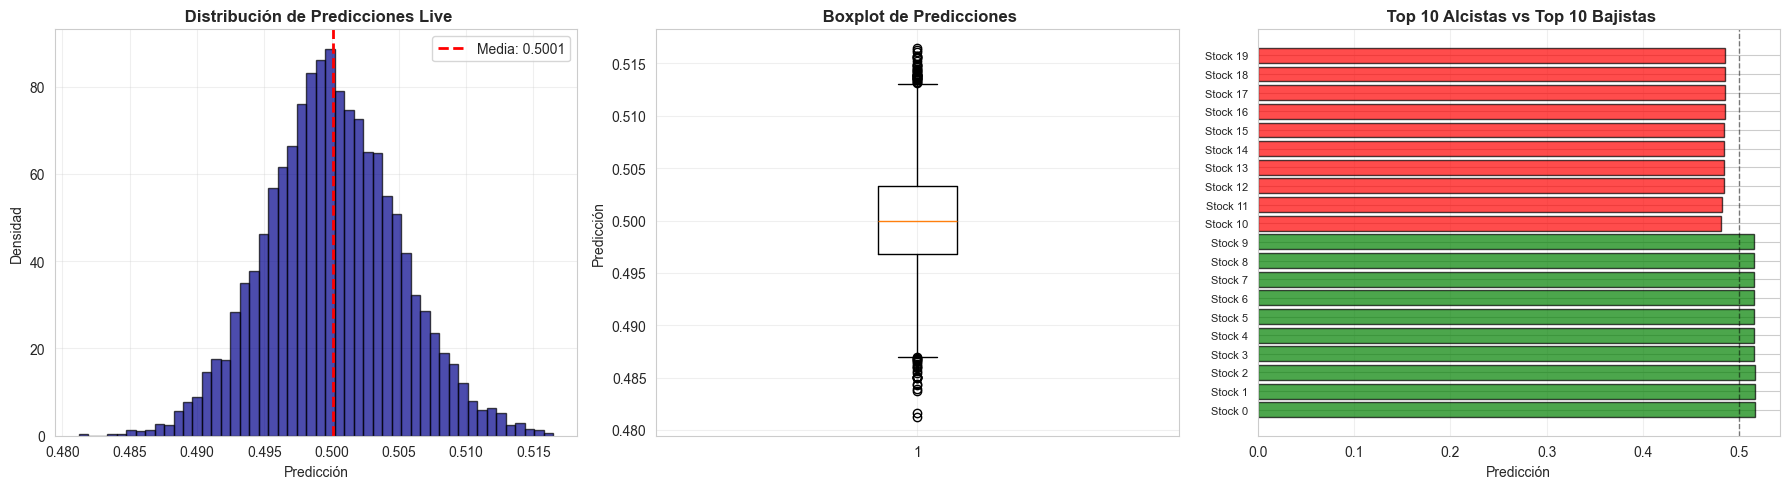


 Interpretación de predicciones live:
   - Valores altos: Stocks con rendimientos esperados positivos
   - Valores bajos: Stocks con rendimientos esperados negativos
   - En producción, estas predicciones se rankean y usan para tomar decisiones de inversión


In [37]:
# Visualización de predicciones live
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de predicciones
axes[0].hist(submission['prediction'], bins=50, color='darkblue', edgecolor='black', alpha=0.7, density=True)
axes[0].set_title(' Distribución de Predicciones Live', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Densidad')
axes[0].axvline(x=submission['prediction'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {submission["prediction"].mean():.4f}')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Boxplot
axes[1].boxplot(submission['prediction'], vert=True)
axes[1].set_title(' Boxplot de Predicciones', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicción')
axes[1].grid(True, alpha=0.3)

# 3. Top/Bottom predicciones
top_10 = submission.nlargest(10, 'prediction')
bottom_10 = submission.nsmallest(10, 'prediction')

combined = pd.concat([top_10, bottom_10])
colors_bars = ['green' if x > submission['prediction'].median() else 'red' for x in combined['prediction']]

axes[2].barh(range(len(combined)), combined['prediction'], color=colors_bars, edgecolor='black', alpha=0.7)
axes[2].set_yticks(range(len(combined)))
axes[2].set_yticklabels([f"Stock {i}" for i in range(len(combined))], fontsize=8)
axes[2].set_title(' Top 10 Alcistas vs Top 10 Bajistas', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].axvline(x=submission['prediction'].median(), color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n Interpretación de predicciones live:")
print("   - Valores altos: Stocks con rendimientos esperados positivos")
print("   - Valores bajos: Stocks con rendimientos esperados negativos")
print("   - En producción, estas predicciones se rankean y usan para tomar decisiones de inversión")